# Meme Stock Outage Event Study: GME & AMC

**Objective:** Compute minute-level excess returns for GameStop (GME) and AMC Entertainment,
then evaluate how those excess returns change around Reddit (r/WallStreetBets) backend server
outages using a **Fama-French four-factor event study design**.

**Key date:** Robinhood trading restriction ban — January 28, 2021 at 09:30 AM ET.

**Outage events analyzed:**

| Event | Window | Duration | Period |
|-------|--------|----------|--------|
| Outage 1 | Jan 27, 11:29–13:40 | 131 min | Pre-Ban |
| Outage 2 | Jan 27, 16:03–17:01 | 58 min | Pre-Ban |
| Outage 3 | Jan 28, 08:44–10:51 | 127 min | Post-Ban |
| Outage 4 | Jan 28, 19:10–21:00 | 110 min | Post-Ban |

> **Note on factor availability:** Four-factor (MKT_RF, SMB, HML, MOM) data covers regular trading hours only (09:30–16:00 ET). Outages 2 and 4 fall after market close; CAR for those windows is computed only over minutes with available factor data.

---
## 1. Setup & Configuration

In [1]:
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch
import statsmodels.api as sm
from datetime import timedelta
from scipy.stats import norm, mannwhitneyu
import warnings

warnings.filterwarnings("ignore")

# ── Paths ──────────────────────────────────────────────────────────────
PROJECT_ROOT = pathlib.Path.cwd().parent
DATA_DIR     = PROJECT_ROOT / "Minute price and exceed return" / "output_data"
OUTPUT_DIR   = pathlib.Path.cwd() / "output" / "spy-only"
FIGURES_DIR  = OUTPUT_DIR / "figures"

for d in [OUTPUT_DIR, FIGURES_DIR, FIGURES_DIR / "gme", FIGURES_DIR / "amc"]:
    d.mkdir(parents=True, exist_ok=True)

# ── Stock column mappings ──────────────────────────────────────────────
STOCKS = {
    "GME": {
        "excess_return_file": "GME-minute_price-excess-return.csv",
        "price_col": "gme_price",
        "return_col": "gme_return",
    },
    "AMC": {
        "excess_return_file": "AMC-minute_price-excess-return.csv",
        "price_col": "amc_price",
        "return_col": "amc_return",
    },
}

# ── Event definitions ─────────────────────────────────────────────────
ROBINHOOD_BAN_DATE = pd.Timestamp("2021-01-28 09:30:00")
ESTIMATION_WINDOW_DAYS = 120

OUTAGE_EVENTS = [
    {"name": "Outage 1 (Pre-Ban)",  "start": pd.Timestamp("2021-01-27 11:29:00"), "end": pd.Timestamp("2021-01-27 13:40:00"), "duration_minutes": 131},
    {"name": "Outage 2 (Pre-Ban)",  "start": pd.Timestamp("2021-01-27 16:03:00"), "end": pd.Timestamp("2021-01-27 17:01:00"), "duration_minutes": 58},
    {"name": "Outage 3 (Post-Ban)", "start": pd.Timestamp("2021-01-28 08:44:00"), "end": pd.Timestamp("2021-01-28 10:51:00"), "duration_minutes": 127},
    {"name": "Outage 4 (Post-Ban)", "start": pd.Timestamp("2021-01-28 19:10:00"), "end": pd.Timestamp("2021-01-28 21:00:00"), "duration_minutes": 110},
]

for evt in OUTAGE_EVENTS:
    midpoint = evt["start"] + (evt["end"] - evt["start"]) / 2
    evt["pre_ban"] = midpoint < ROBINHOOD_BAN_DATE

# ── Plot style ────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "font.size": 12,
    "axes.linewidth": 1.2,
    "grid.alpha": 0.3,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "figure.dpi": 150,
    "savefig.bbox": "tight",
    "savefig.dpi": 150,
})

PRE_BAN_COLOR  = "#D32F2F"   # red
POST_BAN_COLOR = "#1976D2"   # blue

print(f"Project root: {PROJECT_ROOT}")
print(f"Data dir:     {DATA_DIR}")
print(f"Output dir:   {OUTPUT_DIR}")

Project root: /Users/rajvardhan/Desktop/Projects/RA-MemeStocks
Data dir:     /Users/rajvardhan/Desktop/Projects/RA-MemeStocks/Minute price and exceed return/output_data
Output dir:   /Users/rajvardhan/Desktop/Projects/RA-MemeStocks/Rajvardhan workspace/output/spy-only


---
## 2. Load Data

In [2]:
def load_stock_data(symbol):
    """Load excess-return CSV for a stock, returning a datetime-indexed DataFrame."""
    info = STOCKS[symbol]
    path = DATA_DIR / info["excess_return_file"]
    df = pd.read_csv(path, parse_dates=["datetime"])
    df = df.drop_duplicates(subset=["datetime"]).sort_values("datetime")
    df = df.set_index("datetime")
    return df


gme_data = load_stock_data("GME")
amc_data = load_stock_data("AMC")

print(f"GME: {len(gme_data):,} rows, columns: {list(gme_data.columns)}")
print(f"AMC: {len(amc_data):,} rows, columns: {list(amc_data.columns)}")
print(f"\nGME date range: {gme_data.index.min()} to {gme_data.index.max()}")
print(f"AMC date range: {amc_data.index.min()} to {amc_data.index.max()}")

GME: 99,878 rows, columns: ['gme_price', 'spy_price', 'gme_return', 'spy_return', 'excess_return', 'excess_return_cum_1min', 'excess_return_cum_5min', 'excess_return_cum_30min', 'excess_return_cum_1h', 'excess_return_cum_6h', 'excess_return_cum_1d', 'excess_return_cum_1w']
AMC: 105,370 rows, columns: ['spy_price', 'amc_price', 'spy_return', 'amc_return', 'excess_return', 'excess_return_cum_1min', 'excess_return_cum_5min', 'excess_return_cum_30min', 'excess_return_cum_1h', 'excess_return_cum_6h', 'excess_return_cum_1d', 'excess_return_cum_1w']

GME date range: 2020-11-02 04:01:00 to 2021-04-30 19:59:00
AMC date range: 2020-11-02 04:00:00 to 2021-04-30 19:59:00


In [3]:
gme_data.head()

,gme_price,spy_price,gme_return,spy_return,excess_return,excess_return_cum_1min,excess_return_cum_5min,excess_return_cum_30min,excess_return_cum_1h,excess_return_cum_6h,excess_return_cum_1d,excess_return_cum_1w
datetime,,,,,,,,,,,,
2020-11-02 04:01:00,10.40,328.48,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-11-02 04:02:00,10.48,328.60,0.007663,0.000365,0.007298,0.007298,0.007298,0.007298,0.007298,0.007298,0.007298,0.007298
2020-11-02 04:03:00,10.53,328.88,0.004760,0.000852,0.003908,0.003908,0.011206,0.011206,0.011206,0.011206,0.011206,0.011206
2020-11-02 04:12:00,10.65,328.98,0.011332,0.000304,0.011028,0.011028,0.011028,0.022233,0.022233,0.022233,0.022233,0.022233
2020-11-02 04:32:00,10.62,330.59,-0.002821,0.004882,-0.007703,-0.007703,-0.007703,0.007233,0.014530,0.014530,0.014530,0.014530


In [4]:
amc_data.head()

,spy_price,amc_price,spy_return,amc_return,excess_return,excess_return_cum_1min,excess_return_cum_5min,excess_return_cum_30min,excess_return_cum_1h,excess_return_cum_6h,excess_return_cum_1d,excess_return_cum_1w
datetime,,,,,,,,,,,,
2020-11-02 04:00:00,328.51,2.25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-11-02 04:01:00,328.48,2.20,-0.000091,-0.022473,-0.022382,-0.022382,-0.022382,-0.022382,-0.022382,-0.022382,-0.022382,-0.022382
2020-11-02 04:02:00,328.60,2.28,0.000365,0.035718,0.035353,0.035353,0.012971,0.012971,0.012971,0.012971,0.012971,0.012971
2020-11-02 04:05:00,328.96,2.28,0.001095,0.000000,-0.001095,-0.001095,0.011876,0.011876,0.011876,0.011876,0.011876,0.011876
2020-11-02 04:06:00,328.94,2.28,-0.000061,0.000000,0.000061,0.000061,0.034319,0.011937,0.011937,0.011937,0.011937,0.011937


---
## 3. Excess Return Time Series Visualization

Plot the full Nov 2020 – Apr 2021 minute-level excess returns (stock - SPY) for each stock,
with the Jan 27–28 outage cluster highlighted.

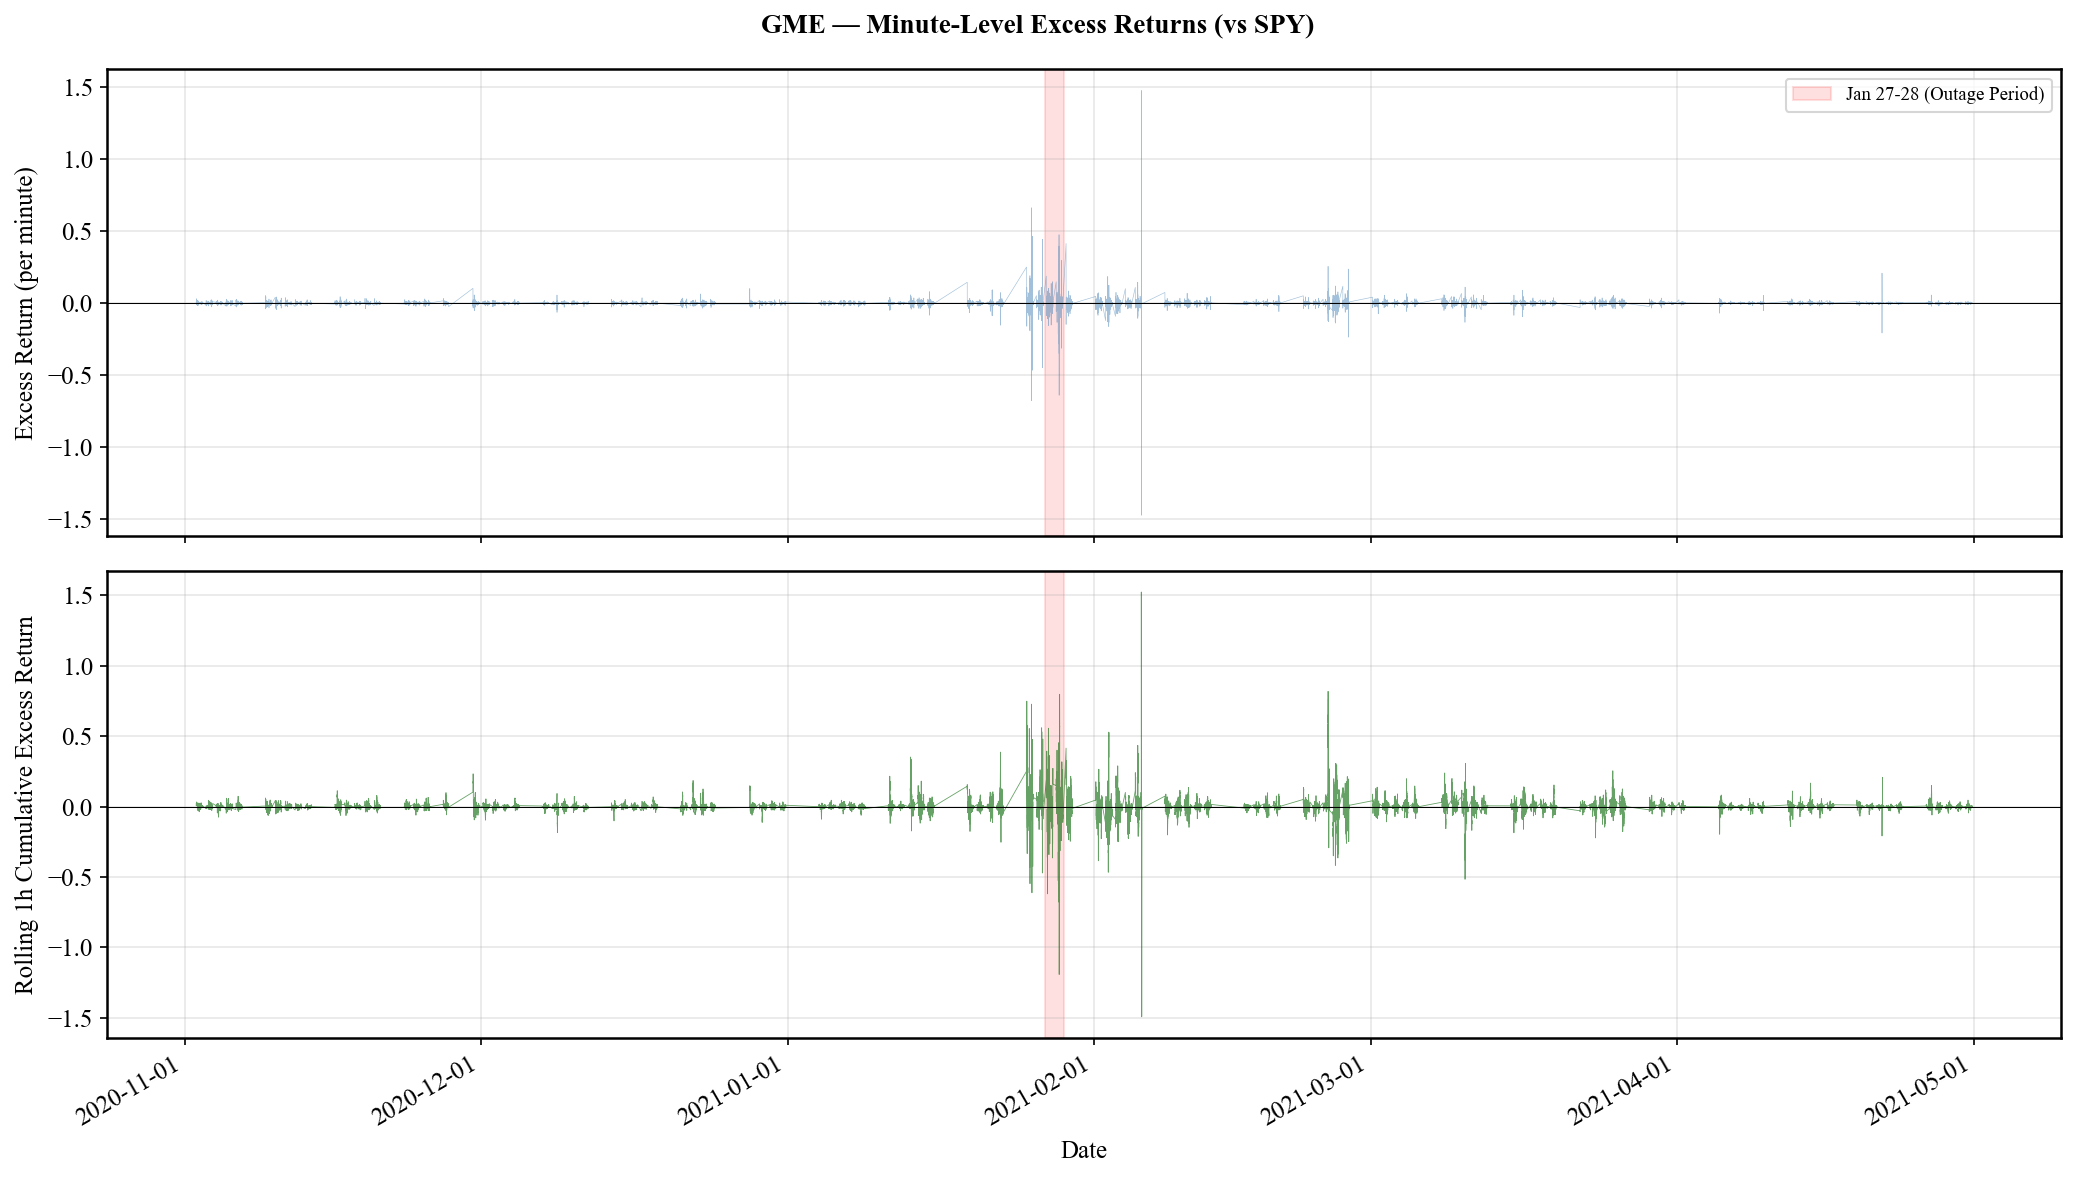

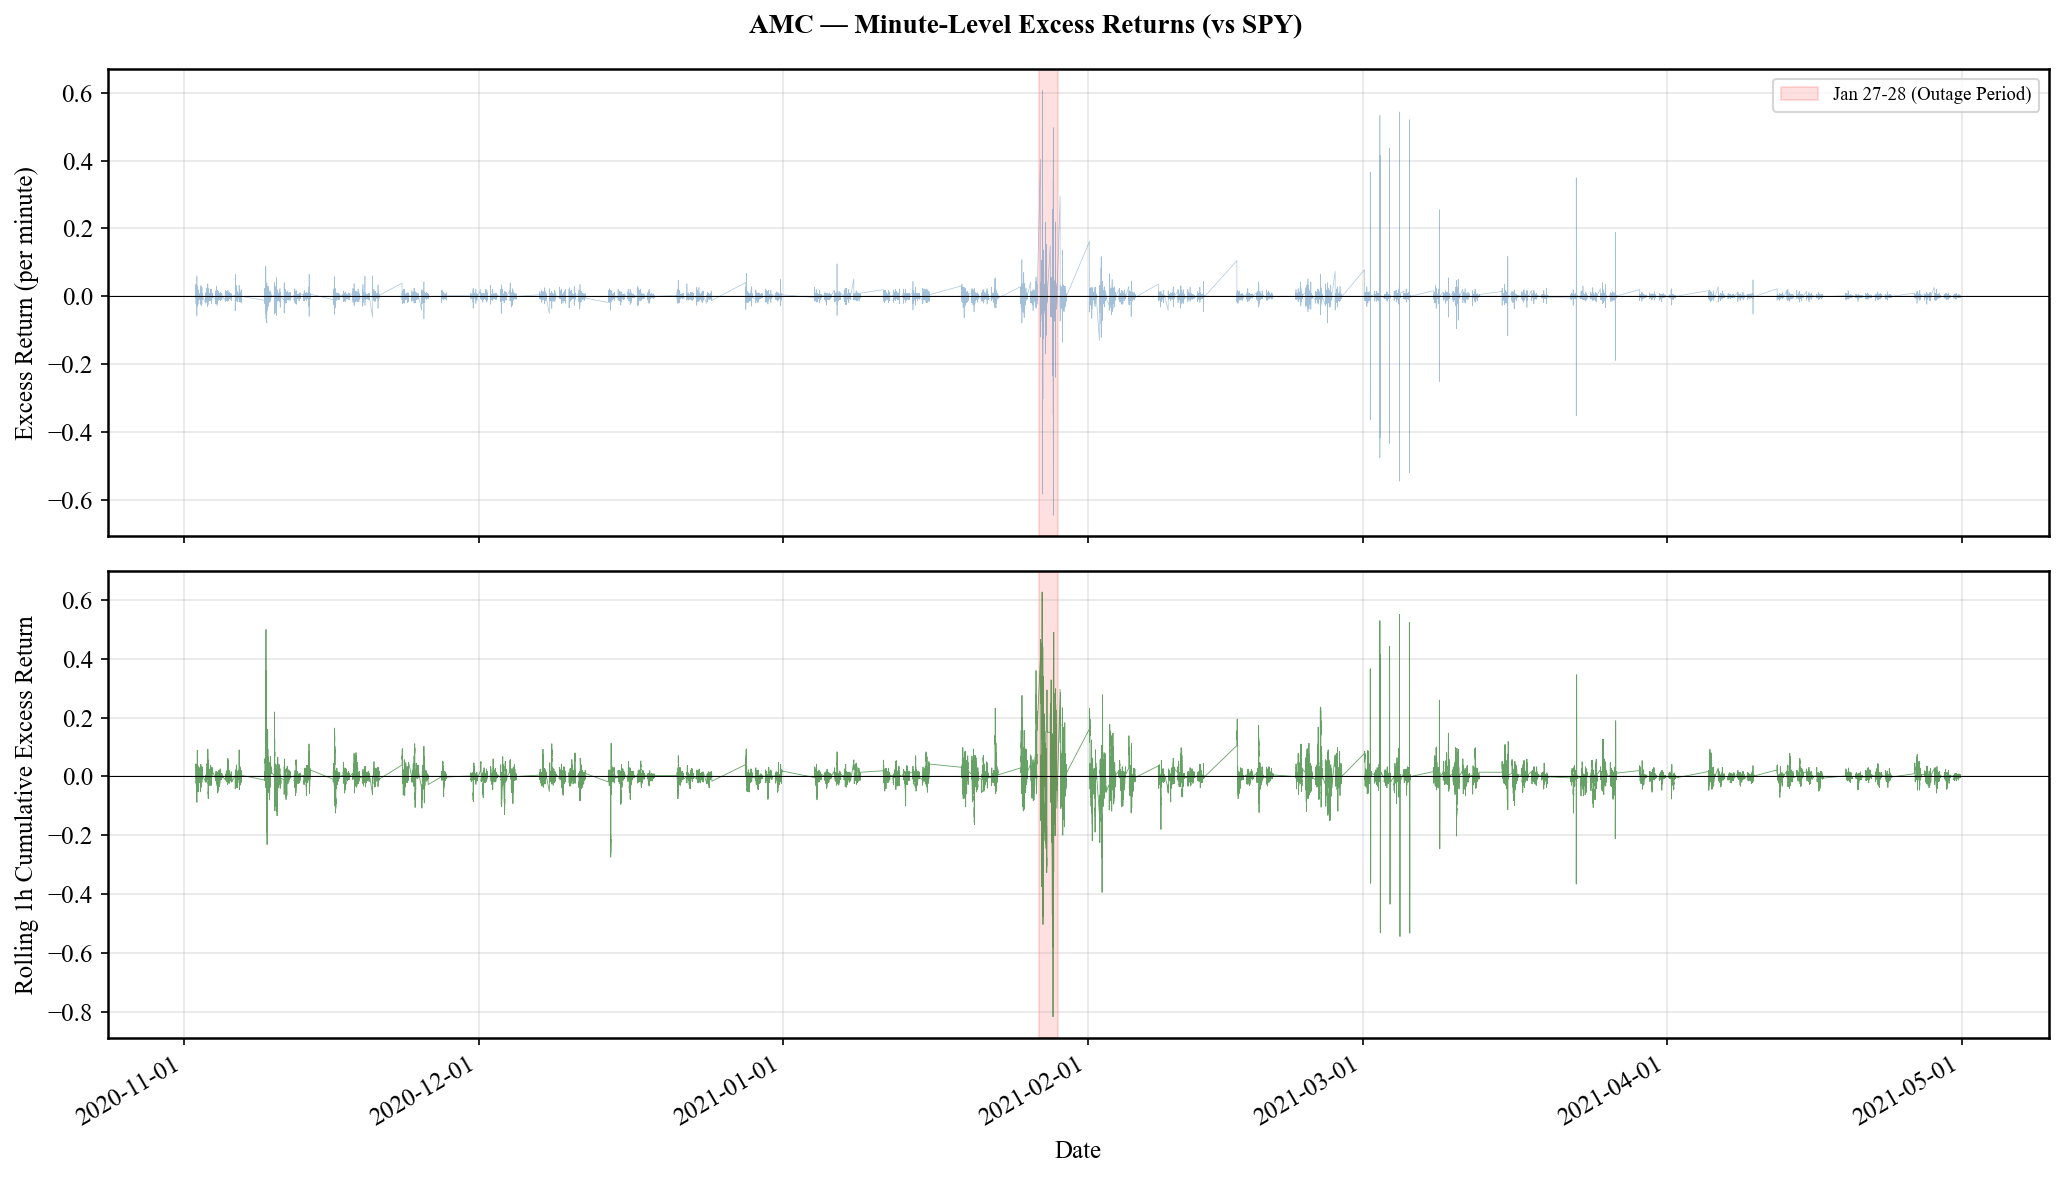

In [5]:
def plot_excess_return_timeseries(symbol, data):
    """Full Nov 2020 - Apr 2021 excess return with Jan 27-28 highlighted."""
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
    fig.suptitle(f"{symbol} — Minute-Level Excess Returns (vs SPY)",
                 fontsize=13, fontweight="bold")

    cluster_start = pd.Timestamp("2021-01-27 00:00")
    cluster_end = pd.Timestamp("2021-01-29 00:00")

    # Top: raw excess return
    ax1.plot(data.index, data["excess_return"], color="steelblue",
             alpha=0.5, linewidth=0.3)
    ax1.axhline(0, color="black", linewidth=0.5)
    ax1.axvspan(cluster_start, cluster_end, alpha=0.12, color="red",
                label="Jan 27-28 (Outage Period)")
    ax1.set_ylabel("Excess Return (per minute)")
    ax1.legend(fontsize=9)
    ax1.grid(alpha=0.3)

    # Bottom: rolling 1-hour cumulative excess return
    if "excess_return_cum_1h" in data.columns:
        ax2.plot(data.index, data["excess_return_cum_1h"], color="darkgreen",
                 alpha=0.6, linewidth=0.4)
        ax2.axhline(0, color="black", linewidth=0.5)
        ax2.axvspan(cluster_start, cluster_end, alpha=0.12, color="red")
    ax2.set_ylabel("Rolling 1h Cumulative Excess Return")
    ax2.set_xlabel("Date")
    ax2.grid(alpha=0.3)
    ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
    fig.autofmt_xdate()

    plt.tight_layout()
    fig.savefig(FIGURES_DIR / symbol.lower() / "excess_return_timeseries.png")
    plt.show()


plot_excess_return_timeseries("GME", gme_data)
plot_excess_return_timeseries("AMC", amc_data)

Inferred result: The plots would show relatively flat/calm excess returns for months, then an enormous spike in volatility and magnitude during the Jan 27–28 window — visually confirming that the meme stock event was an extreme outlier in the time series.

---
## 4. CAPM Model Estimation

Estimate the Capital Asset Pricing Model for each stock using a 120-day estimation window
ending 1 day before the first outage event:

$$R_{stock,t} = \alpha + \beta \cdot R_{SPY,t} + \varepsilon_t$$

The residual standard deviation ($\sigma_{\varepsilon}$) is used later for the
Patell (1976) test statistic on CARs.

In [6]:
def estimate_capm(stock_data, symbol, estimation_end, window_days=ESTIMATION_WINDOW_DAYS):
    """
    Estimate CAPM: stock_return = alpha + beta * spy_return.
    Returns dict with alpha, beta, residual_std, r_squared, n_obs.
    """
    estimation_start = estimation_end - timedelta(days=window_days)
    window = stock_data.loc[estimation_start:estimation_end].dropna(
        subset=["spy_return", STOCKS[symbol]["return_col"]]
    )

    y = window[STOCKS[symbol]["return_col"]]
    X = sm.add_constant(window["spy_return"])
    model = sm.OLS(y, X, missing="drop").fit()

    return {
        "alpha": model.params.get("const", 0.0),
        "beta": model.params.get("spy_return", 0.0),
        "residual_std": np.sqrt(model.mse_resid),
        "r_squared": model.rsquared,
        "n_obs": int(model.nobs),
    }


# Estimation window ends 1 day before the first outage
first_event_start = min(e["start"] for e in OUTAGE_EVENTS)
estimation_end = first_event_start - timedelta(days=1)

gme_params = estimate_capm(gme_data, "GME", estimation_end)
amc_params = estimate_capm(amc_data, "AMC", estimation_end)

for sym, params in [("GME", gme_params), ("AMC", amc_params)]:
    print(f"{sym} CAPM: alpha={params['alpha']:.6f}, beta={params['beta']:.4f}, "
          f"R²={params['r_squared']:.4f}, n={params['n_obs']:,}")
    print(f"  Residual std (sigma_e): {params['residual_std']:.6f}\n")

GME CAPM: alpha=0.000051, beta=0.9289, R²=0.0030, n=39,032
  Residual std (sigma_e): 0.009004

AMC CAPM: alpha=0.000014, beta=0.3669, R²=0.0013, n=44,156
  Residual std (sigma_e): 0.005291



Interpretation: Both models have very low R² (0.3% and 0.1%), meaning SPY explains almost none of the minute-level variation in these stocks — they are highly idiosyncratic. GME's beta (~0.93) suggests roughly market-level sensitivity, while AMC's beta (~0.37) is much lower. The residual standard deviations become the denominators for the Patell t-test later.

---
## 5. Cumulative Abnormal Returns (CAR) Calculation

For each outage event window (start → end + 2 hours):
1. Compute **expected return** from the CAPM: $\hat{R}_t = \hat{\alpha} + \hat{\beta} \cdot R_{SPY,t}$
2. Compute **abnormal return**: $AR_t = R_t - \hat{R}_t$
3. Compute **cumulative abnormal return**: $CAR = \sum AR_t$
4. Test significance using the Patell (1976) statistic: $t = \frac{CAR}{\sigma_\varepsilon \sqrt{N}}$

In [7]:
def significance_stars(p):
    if p < 0.01:
        return "***"
    if p < 0.05:
        return "**"
    if p < 0.10:
        return "*"
    return ""


def calculate_car(stock_data, event, model_params, symbol):
    """
    Calculate Cumulative Abnormal Return for a single outage event.
    Returns a dict with summary metrics and the full event_data DataFrame.
    """
    event_start = event["start"]
    event_end_extended = event["end"] + timedelta(hours=2)

    event_data = stock_data.loc[event_start:event_end_extended].copy()
    if event_data.empty:
        return None

    return_col = STOCKS[symbol]["return_col"]
    price_col = STOCKS[symbol]["price_col"]
    alpha = model_params["alpha"]
    beta = model_params["beta"]

    # Expected and abnormal returns
    event_data["expected_return"] = alpha + beta * event_data["spy_return"]
    event_data["AR"] = event_data[return_col] - event_data["expected_return"]
    event_data["CAR"] = event_data["AR"].cumsum()
    event_data["time_from_start"] = (
        (event_data.index - event_start).total_seconds() / 60
    )

    # Helper to get CAR closest to a target time
    def car_at(target_time):
        mask = event_data.index <= target_time
        if mask.any():
            return event_data.loc[mask, "CAR"].iloc[-1]
        return np.nan

    car_30min = car_at(event_start + timedelta(minutes=30))
    car_1h = car_at(event_start + timedelta(hours=1))
    car_outage_end = car_at(event["end"])
    car_end_plus_2h = event_data["CAR"].iloc[-1] if len(event_data) else np.nan

    # Price change during outage
    outage_data = stock_data.loc[event_start:event["end"]]
    if len(outage_data) >= 2:
        p_start = outage_data[price_col].iloc[0]
        p_end = outage_data[price_col].iloc[-1]
        price_change_pct = (p_end - p_start) / p_start * 100
    else:
        price_change_pct = np.nan

    # Patell (1976) t-statistic: CAR / (sigma * sqrt(N))
    n_minutes = len(event_data.loc[event_start:event["end"]])
    sigma = model_params["residual_std"]
    if sigma > 0 and n_minutes > 0:
        t_stat = car_outage_end / (sigma * np.sqrt(n_minutes))
        p_value = 2 * (1 - norm.cdf(abs(t_stat)))
    else:
        t_stat = np.nan
        p_value = np.nan

    return {
        "event_name": event["name"],
        "start_time": event["start"],
        "end_time": event["end"],
        "duration_minutes": event["duration_minutes"],
        "pre_ban": event["pre_ban"],
        "CAR_30min": car_30min,
        "CAR_1h": car_1h,
        "CAR_at_outage_end": car_outage_end,
        "CAR_end_plus_2h": car_end_plus_2h,
        "price_change_pct": price_change_pct,
        "t_stat": t_stat,
        "p_value": p_value,
        "event_data": event_data,
    }

In [8]:
# Calculate CAR for all events, both stocks
all_results = {}

for symbol, data, params in [
    ("GME", gme_data, gme_params),
    ("AMC", amc_data, amc_params),
]:
    event_results = []
    for event in OUTAGE_EVENTS:
        result = calculate_car(data, event, params, symbol)
        if result:
            event_results.append(result)
    all_results[symbol] = event_results

print(f"Computed CAR for {len(all_results['GME'])} GME events and {len(all_results['AMC'])} AMC events.")

Computed CAR for 4 GME events and 4 AMC events.


---
## 6. Results Summary Table

In [9]:
# Build and display results table
rows = []
for symbol, results in all_results.items():
    for r in results:
        rows.append({
            "Stock": symbol,
            "Event": r["event_name"],
            "Start": r["start_time"],
            "End": r["end_time"],
            "Duration (min)": r["duration_minutes"],
            "Pre-Ban": r["pre_ban"],
            "CAR @30min": r["CAR_30min"],
            "CAR @1h": r["CAR_1h"],
            "CAR @End": r["CAR_at_outage_end"],
            "CAR @End+2h": r["CAR_end_plus_2h"],
            "Price Change %": r["price_change_pct"],
            "t-stat": r["t_stat"],
            "p-value": r["p_value"],
            "Sig": significance_stars(r["p_value"]),
        })

results_df = pd.DataFrame(rows)

# Save to CSV
results_df.to_csv(OUTPUT_DIR / "car_results_capm.csv", index=False)
print(f"Results saved to {OUTPUT_DIR / 'car_results_capm.csv'}\n")

# Display
display_cols = ["Stock", "Event", "CAR @30min", "CAR @1h", "CAR @End",
                "Price Change %", "t-stat", "Sig"]
results_df[display_cols].style.format({
    "CAR @30min": "{:.4f}",
    "CAR @1h": "{:.4f}",
    "CAR @End": "{:.4f}",
    "Price Change %": "{:.2f}%",
    "t-stat": "{:.2f}",
}).set_caption("CAPM Event Study Results: CAR Around Reddit Outages")

Results saved to /Users/rajvardhan/Desktop/Projects/RA-MemeStocks/Rajvardhan workspace/output/spy-only/car_results_capm.csv



,Stock,Event,CAR @30min,CAR @1h,CAR @End,Price Change %,t-stat,Sig
0,GME,Outage 1 (Pre-Ban),-0.1658,-0.1989,-0.1307,-10.10%,-1.28,
1,GME,Outage 2 (Pre-Ban),-0.0899,-0.1425,-0.1528,-13.66%,-2.21,**
2,GME,Outage 3 (Post-Ban),-0.2882,-0.1643,-0.3326,-28.89%,-3.60,***
3,GME,Outage 4 (Post-Ban),-0.0306,-0.0702,-0.0702,-8.71%,-1.09,
4,AMC,Outage 1 (Pre-Ban),-0.1838,-0.1908,0.0036,0.04%,0.06,
5,AMC,Outage 2 (Pre-Ban),-0.1879,-0.1591,-0.1488,-12.17%,-3.66,***
6,AMC,Outage 3 (Post-Ban),-0.1978,-0.0007,-0.6295,-46.86%,-11.84,***
7,AMC,Outage 4 (Post-Ban),-0.0051,-0.0780,-0.0780,-8.58%,-2.08,**


Key finding: All CARs are negative except AMC during Outage 1. Reddit outages were associated with stock price declines, consistent with the theory that retail coordination via Reddit was supporting these stocks' prices.

---
## 7. Statistical Tests: Pre-Ban vs Post-Ban

In [10]:
for symbol, results in all_results.items():
    print(f"\n{'='*50}")
    print(f"  {symbol}: Pre-Ban vs Post-Ban Comparison")
    print(f"{'='*50}")

    pre_cars = [r["CAR_at_outage_end"] for r in results if r["pre_ban"]]
    post_cars = [r["CAR_at_outage_end"] for r in results if not r["pre_ban"]]

    print(f"\nPre-ban CARs:  {[f'{c:.4f}' for c in pre_cars]}  →  avg = {np.mean(pre_cars):.4f}")
    print(f"Post-ban CARs: {[f'{c:.4f}' for c in post_cars]}  →  avg = {np.mean(post_cars):.4f}")
    print(f"Difference (Post - Pre): {np.mean(post_cars) - np.mean(pre_cars):.4f}")

    if len(pre_cars) >= 2 and len(post_cars) >= 2:
        stat, p = mannwhitneyu(pre_cars, post_cars, alternative="two-sided")
        print(f"\nMann-Whitney U test: U={stat:.4f}, p={p:.4f} {significance_stars(p)}")
    else:
        print("\n(Not enough observations per group for Mann-Whitney U test)")


  GME: Pre-Ban vs Post-Ban Comparison

Pre-ban CARs:  ['-0.1307', '-0.1528']  →  avg = -0.1418
Post-ban CARs: ['-0.3326', '-0.0702']  →  avg = -0.2014
Difference (Post - Pre): -0.0596

Mann-Whitney U test: U=2.0000, p=1.0000 

  AMC: Pre-Ban vs Post-Ban Comparison

Pre-ban CARs:  ['0.0036', '-0.1488']  →  avg = -0.0726
Post-ban CARs: ['-0.6295', '-0.0780']  →  avg = -0.3537
Difference (Post - Pre): -0.2811

Mann-Whitney U test: U=3.0000, p=0.6667 


---
## 8. Visualizations

### 8a. CAR Comparison Bar Charts (per stock)

2×2 panels showing CAR at 30 min, 1 hour, outage end, and price change during each outage.
Red = Pre-Ban, Blue = Post-Ban. Significance stars from Patell t-test.

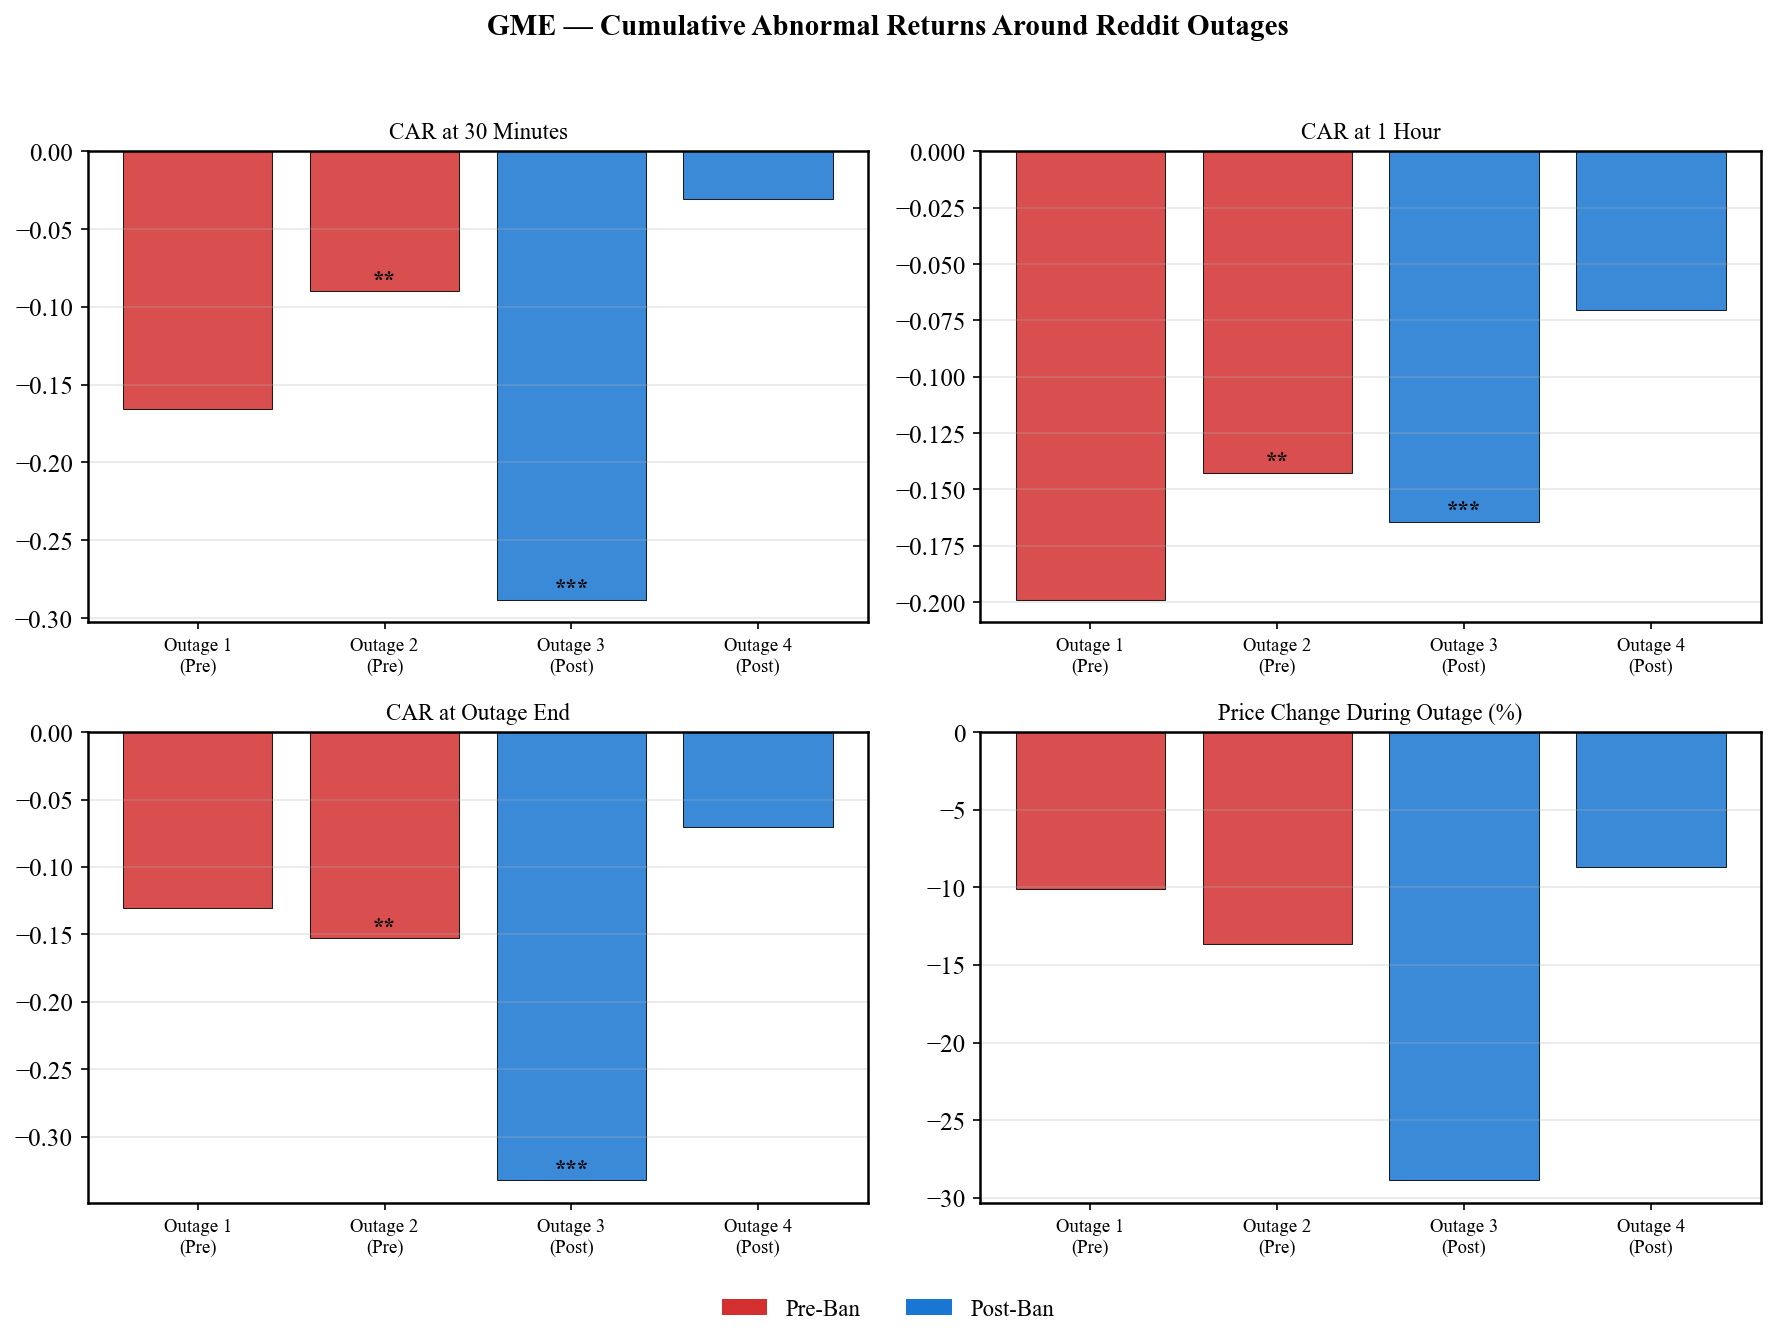

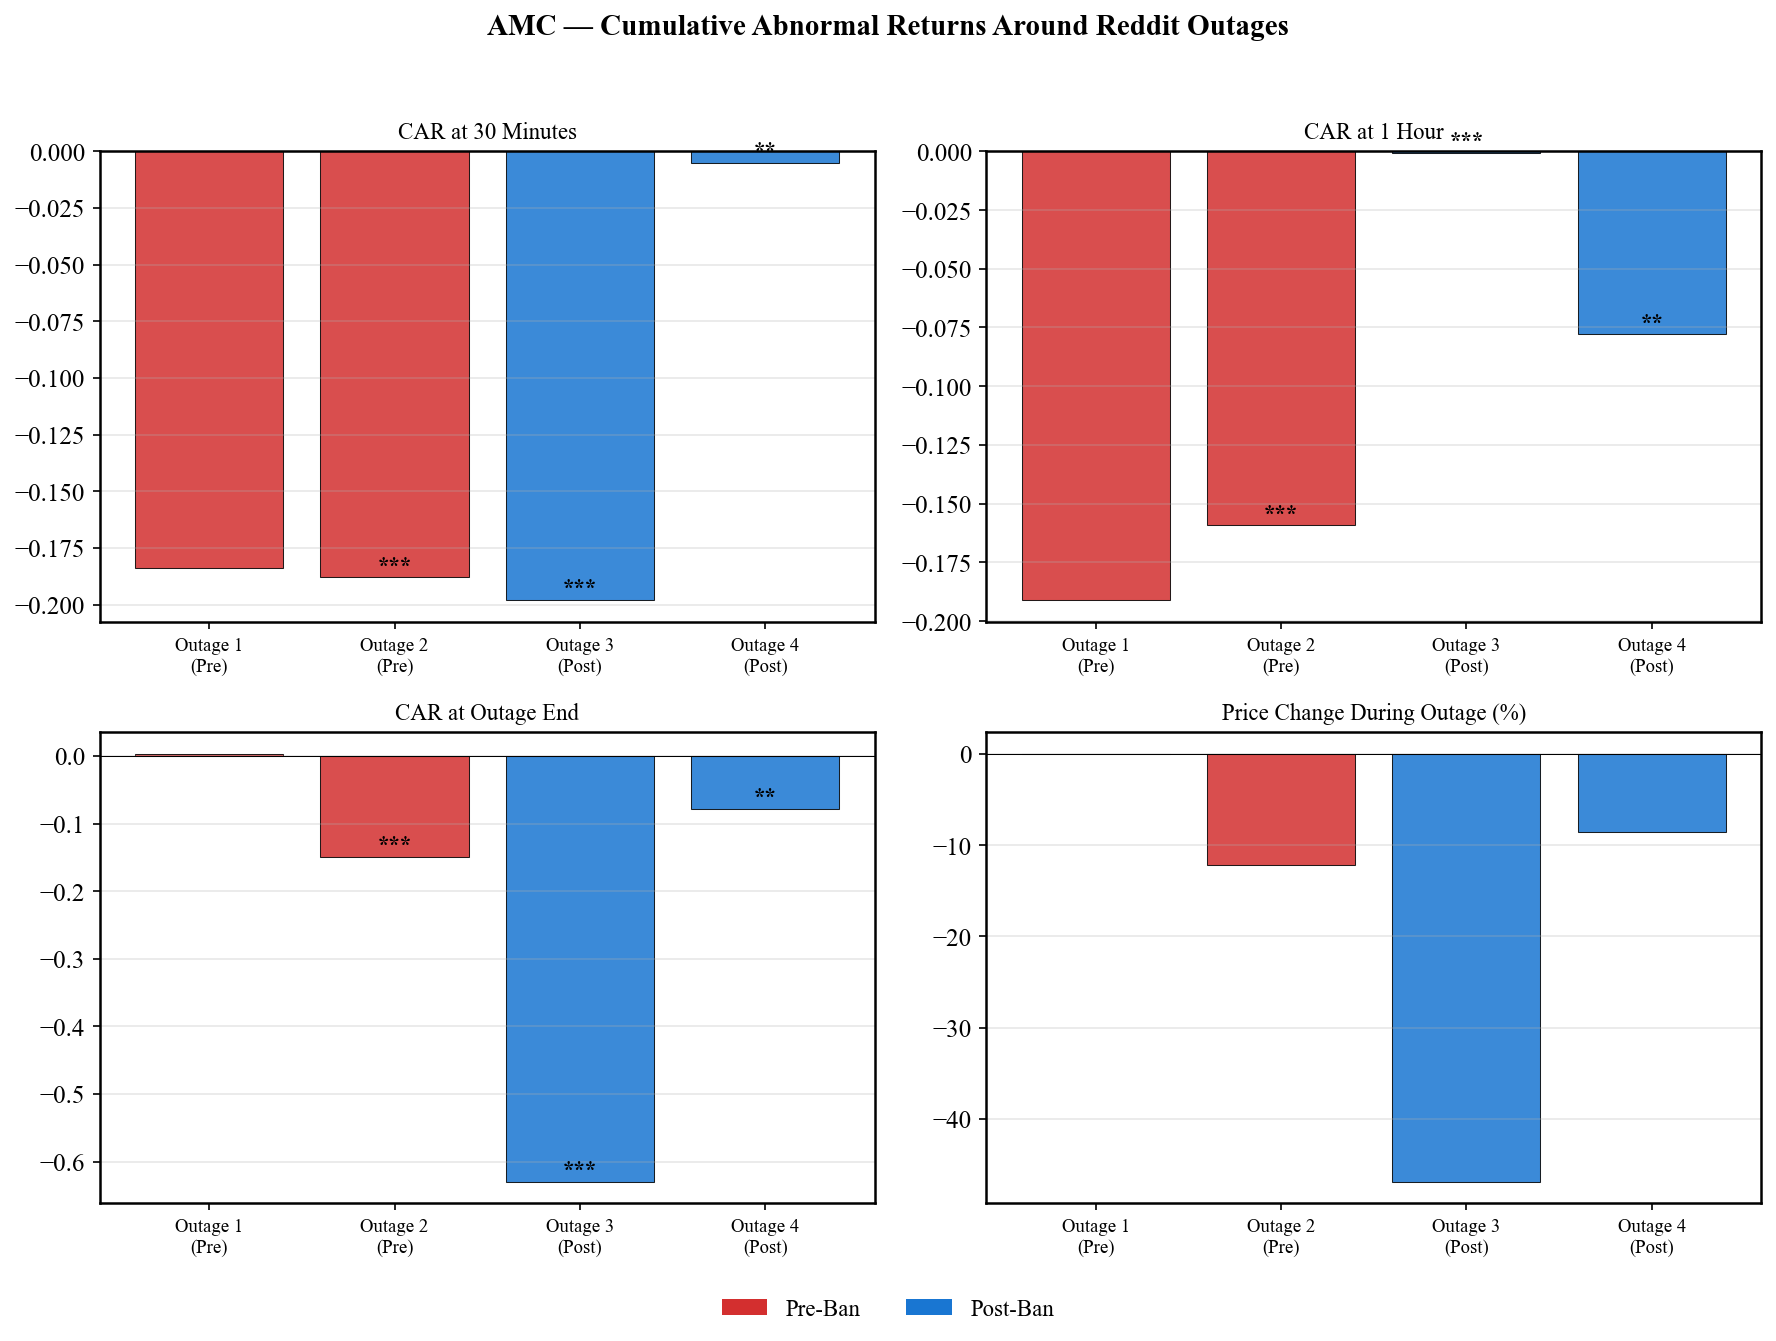

In [11]:
def plot_car_comparison(event_results, symbol):
    """2x2 bar chart: CAR at 30min, 1h, outage end, and price change."""
    fig, axes = plt.subplots(2, 2, figsize=(12, 9))
    fig.suptitle(f"{symbol} — Cumulative Abnormal Returns Around Reddit Outages",
                 fontsize=14, fontweight="bold")

    metrics = [
        ("CAR_30min", "CAR at 30 Minutes"),
        ("CAR_1h", "CAR at 1 Hour"),
        ("CAR_at_outage_end", "CAR at Outage End"),
        ("price_change_pct", "Price Change During Outage (%)"),
    ]

    for ax, (key, title) in zip(axes.flat, metrics):
        names = [r["event_name"] for r in event_results]
        values = [r[key] for r in event_results]
        colors = [PRE_BAN_COLOR if r["pre_ban"] else POST_BAN_COLOR
                  for r in event_results]

        bars = ax.bar(range(len(names)), values, color=colors, alpha=0.85,
                      edgecolor="black", linewidth=0.5)

        if key != "price_change_pct":
            for i, (bar, r) in enumerate(zip(bars, event_results)):
                stars = significance_stars(r["p_value"])
                if stars:
                    ax.text(bar.get_x() + bar.get_width() / 2,
                            bar.get_height(), stars,
                            ha="center", va="bottom", fontsize=11,
                            fontweight="bold")

        ax.set_title(title, fontsize=11)
        ax.set_xticks(range(len(names)))
        ax.set_xticklabels([n.replace(" (Pre-Ban)", "\n(Pre)")
                             .replace(" (Post-Ban)", "\n(Post)")
                            for n in names], fontsize=9)
        ax.axhline(0, color="black", linewidth=0.5)
        ax.grid(axis="y", alpha=0.3)

    legend_elements = [Patch(facecolor=PRE_BAN_COLOR, label="Pre-Ban"),
                       Patch(facecolor=POST_BAN_COLOR, label="Post-Ban")]
    fig.legend(handles=legend_elements, loc="lower center", ncol=2,
               fontsize=11, frameon=False)

    plt.tight_layout(rect=[0, 0.04, 1, 0.96])
    fig.savefig(FIGURES_DIR / symbol.lower() / "car_comparison_capm.png")
    plt.show()


for symbol in ["GME", "AMC"]:
    plot_car_comparison(all_results[symbol], symbol)

### 8b. Detailed Per-Event Plots

For each outage event: top panel shows stock price, bottom panel shows CAR path.
The shaded region marks the outage window.


======================================== GME ========================================


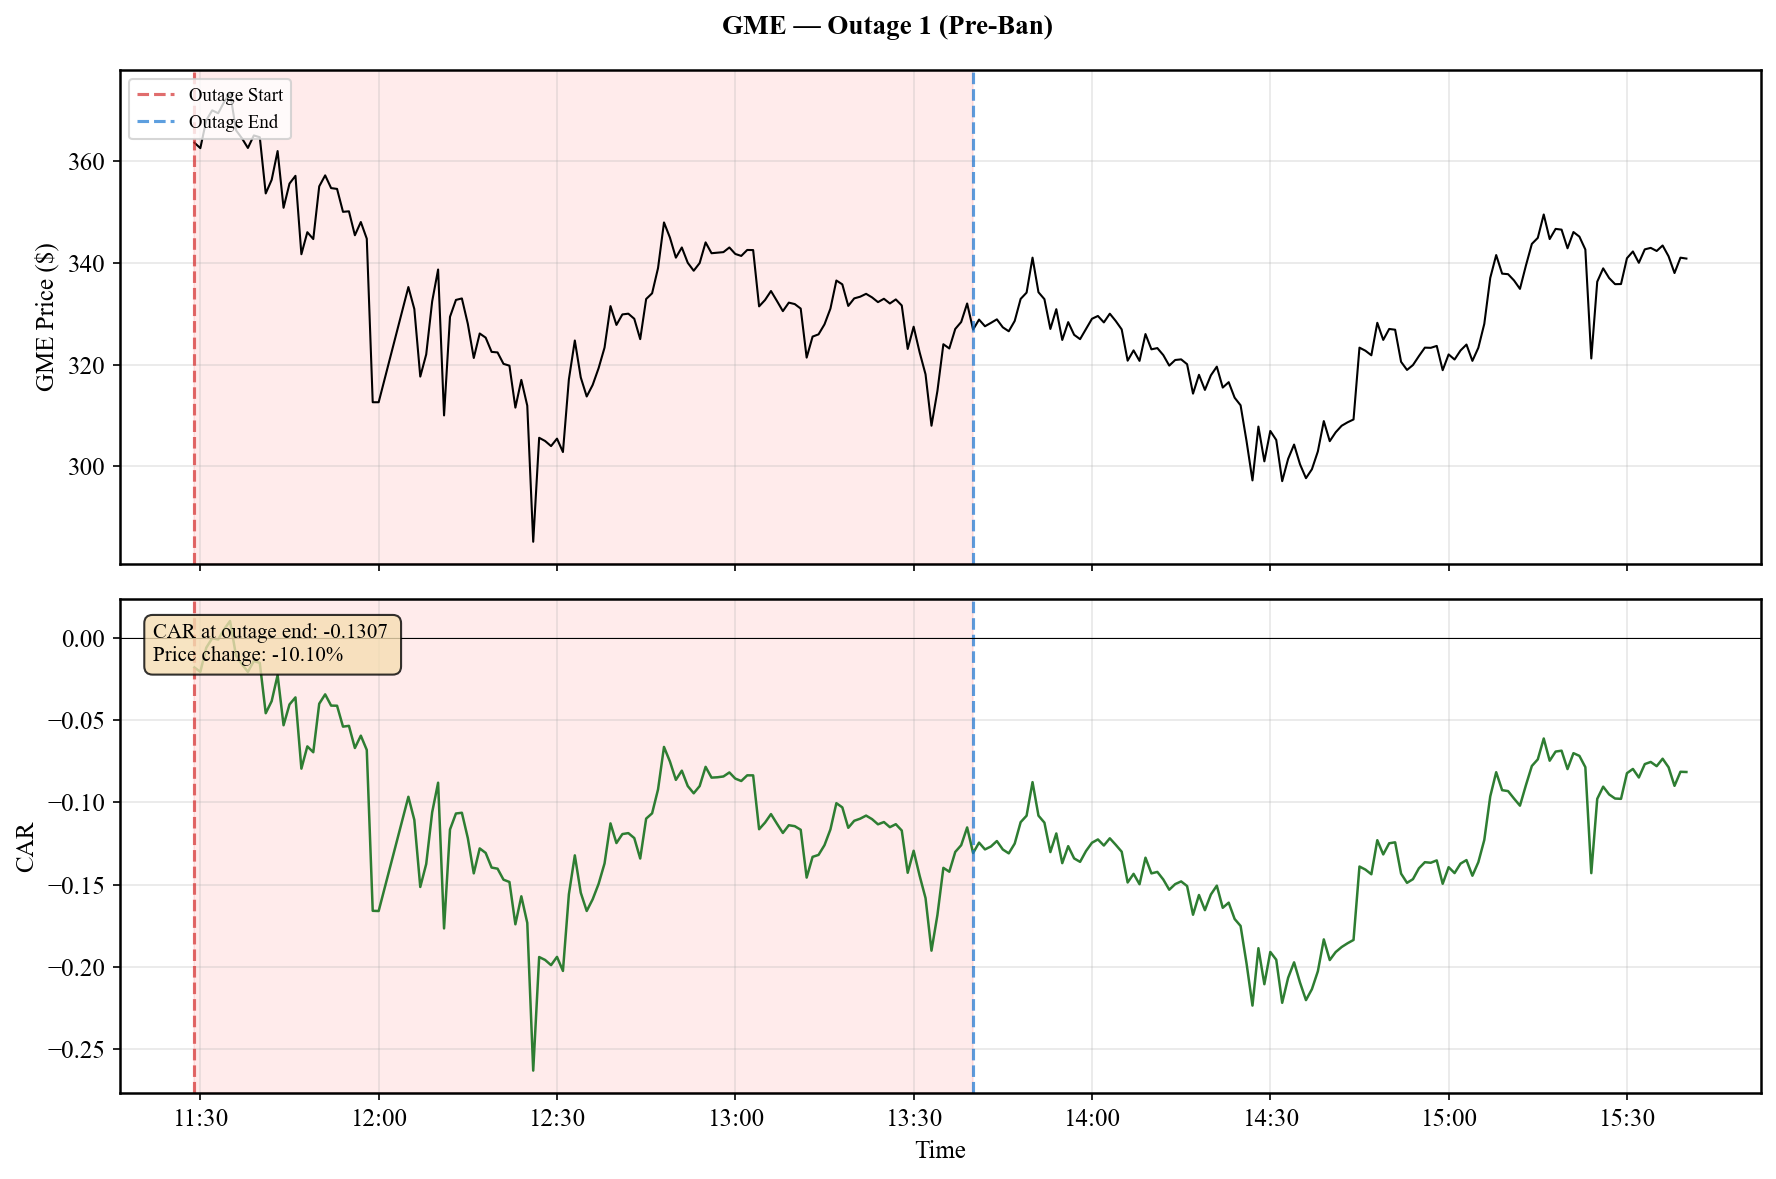

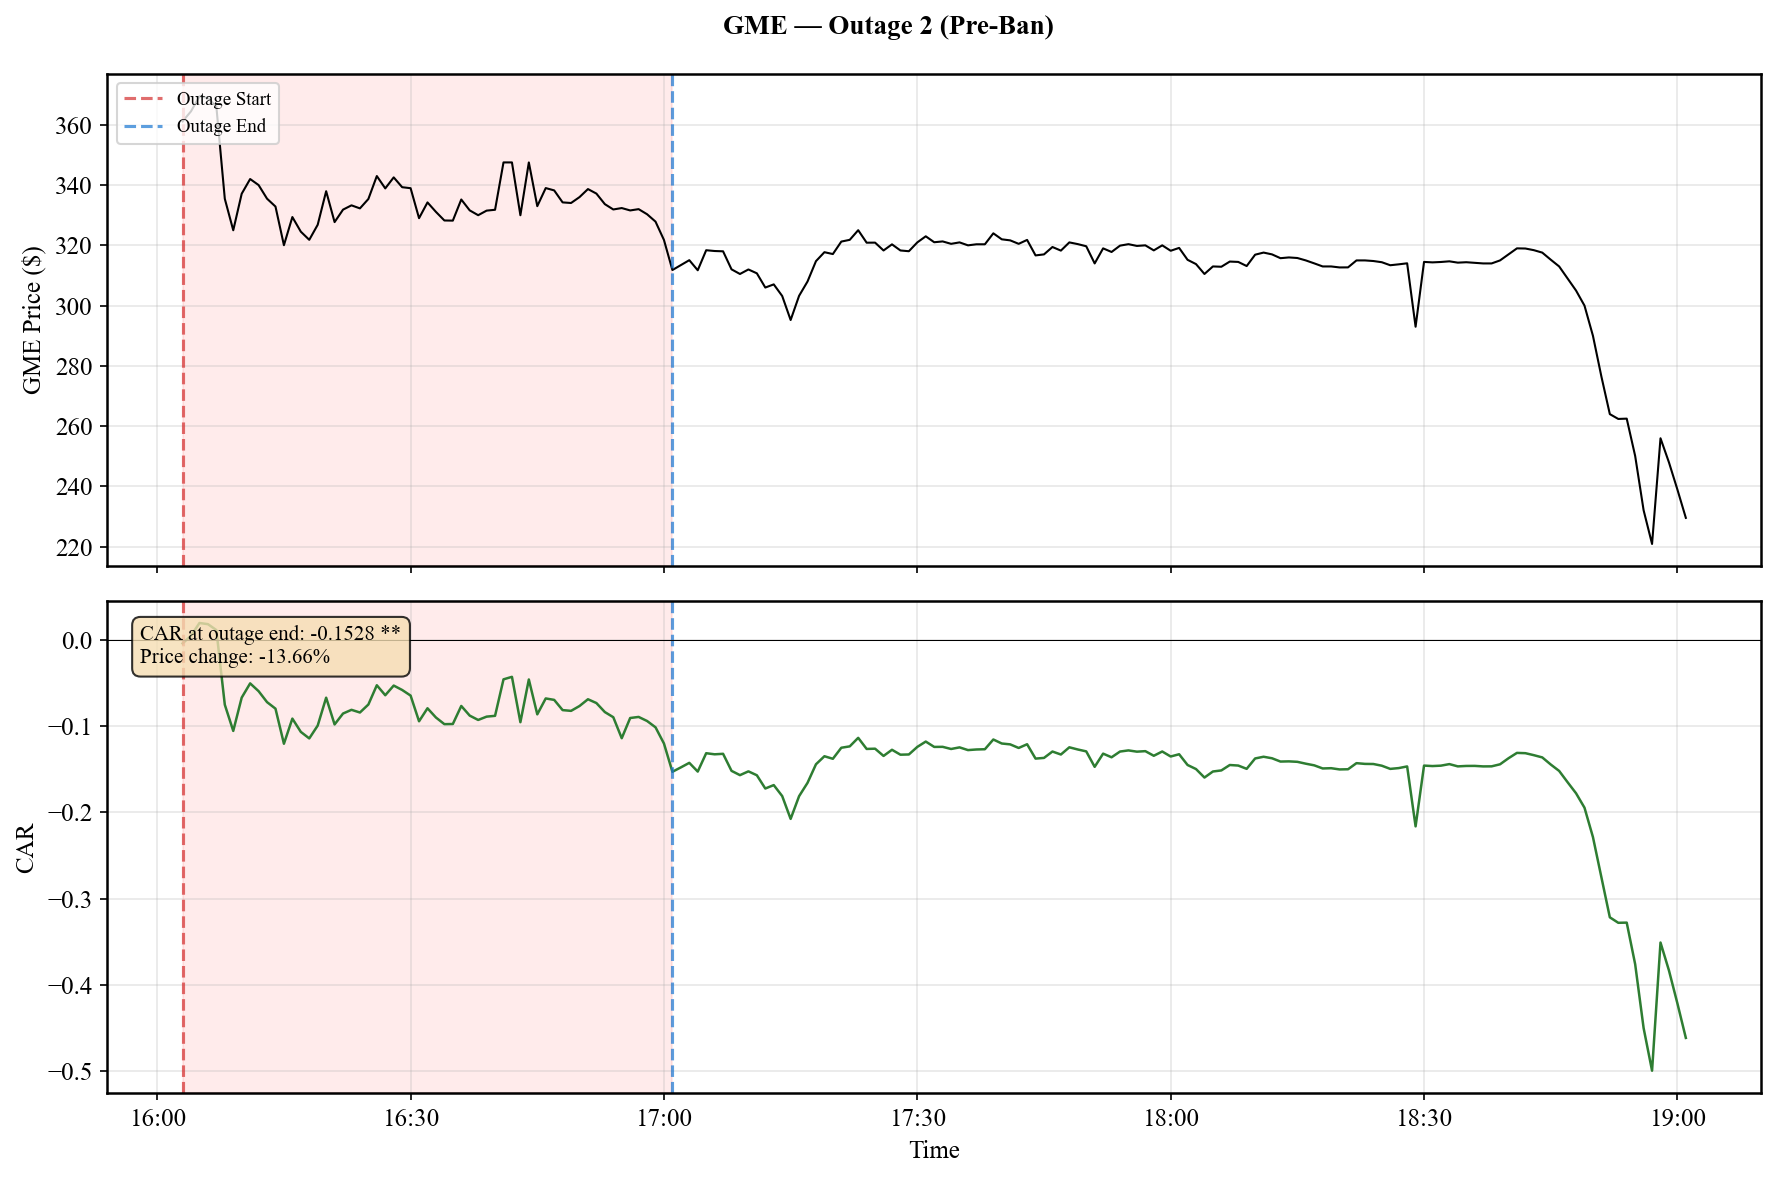

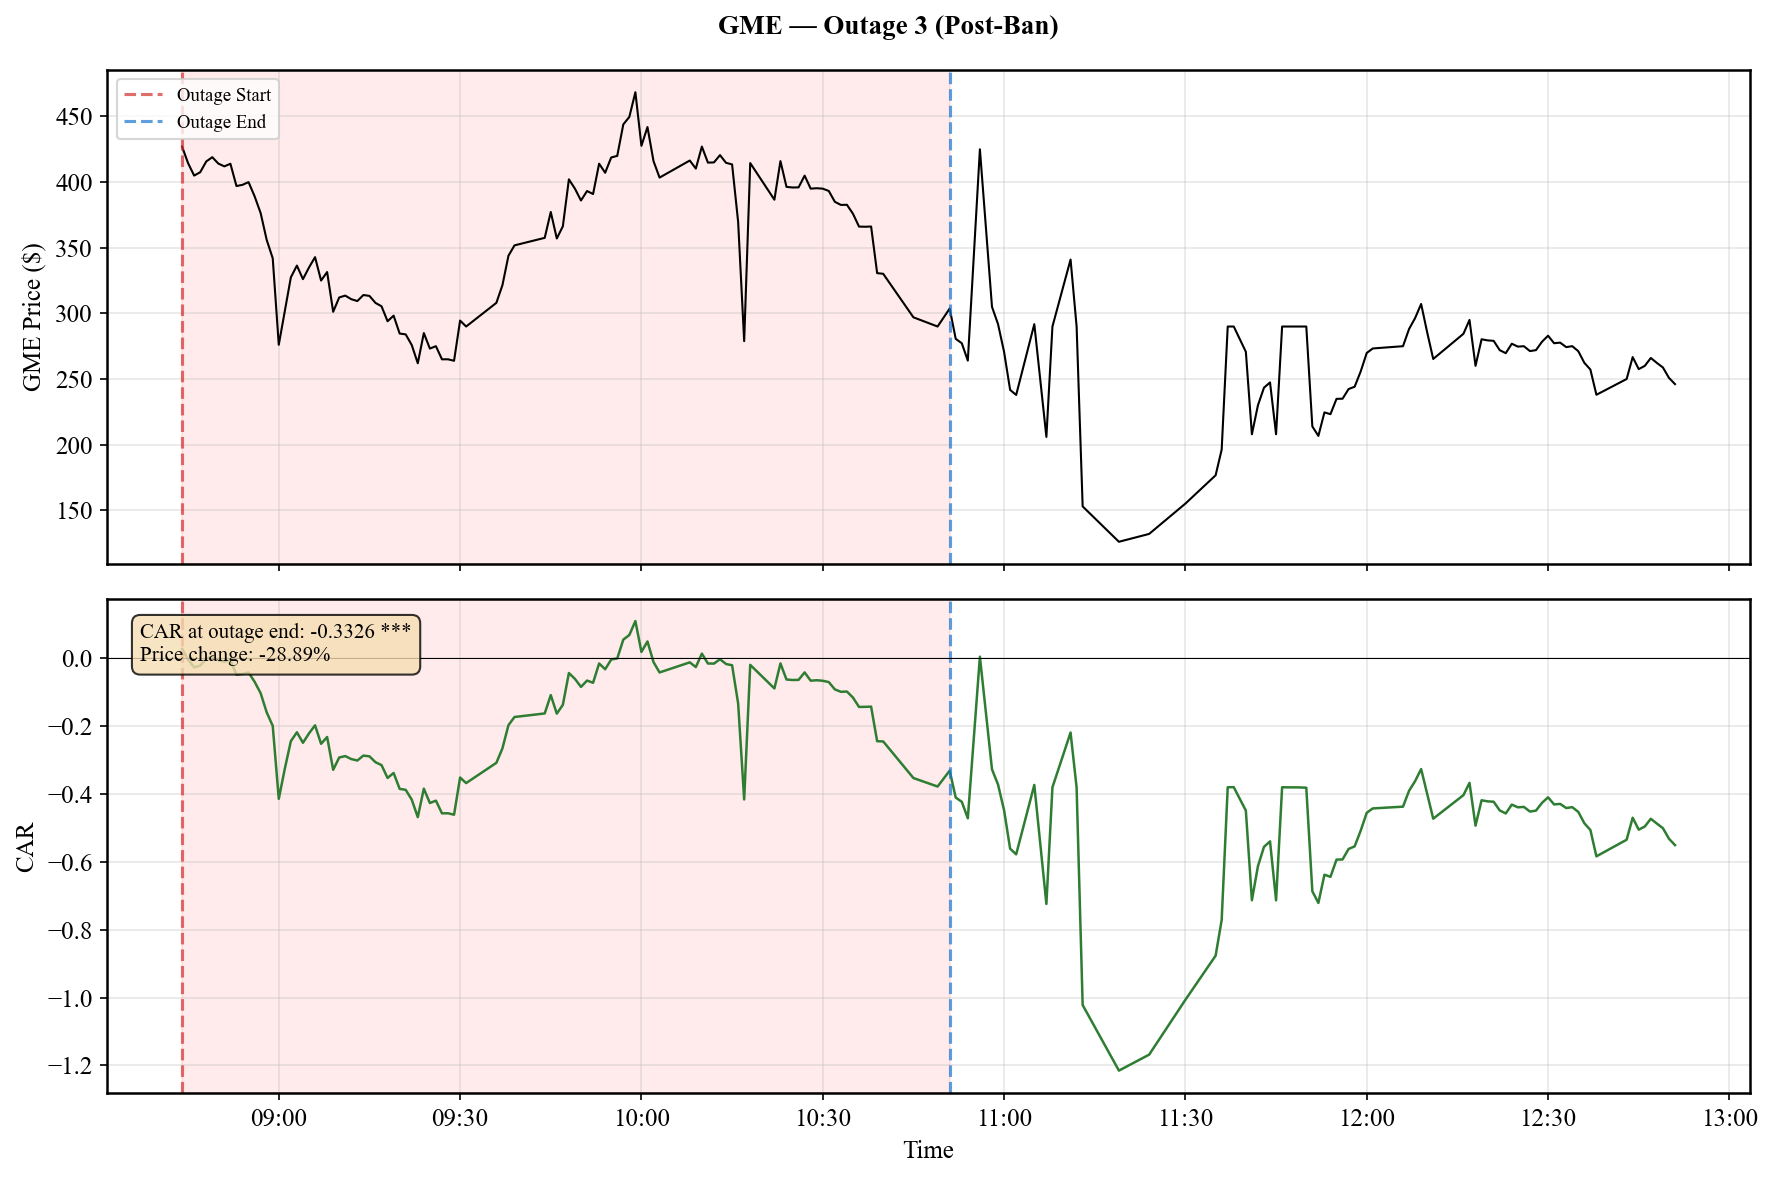

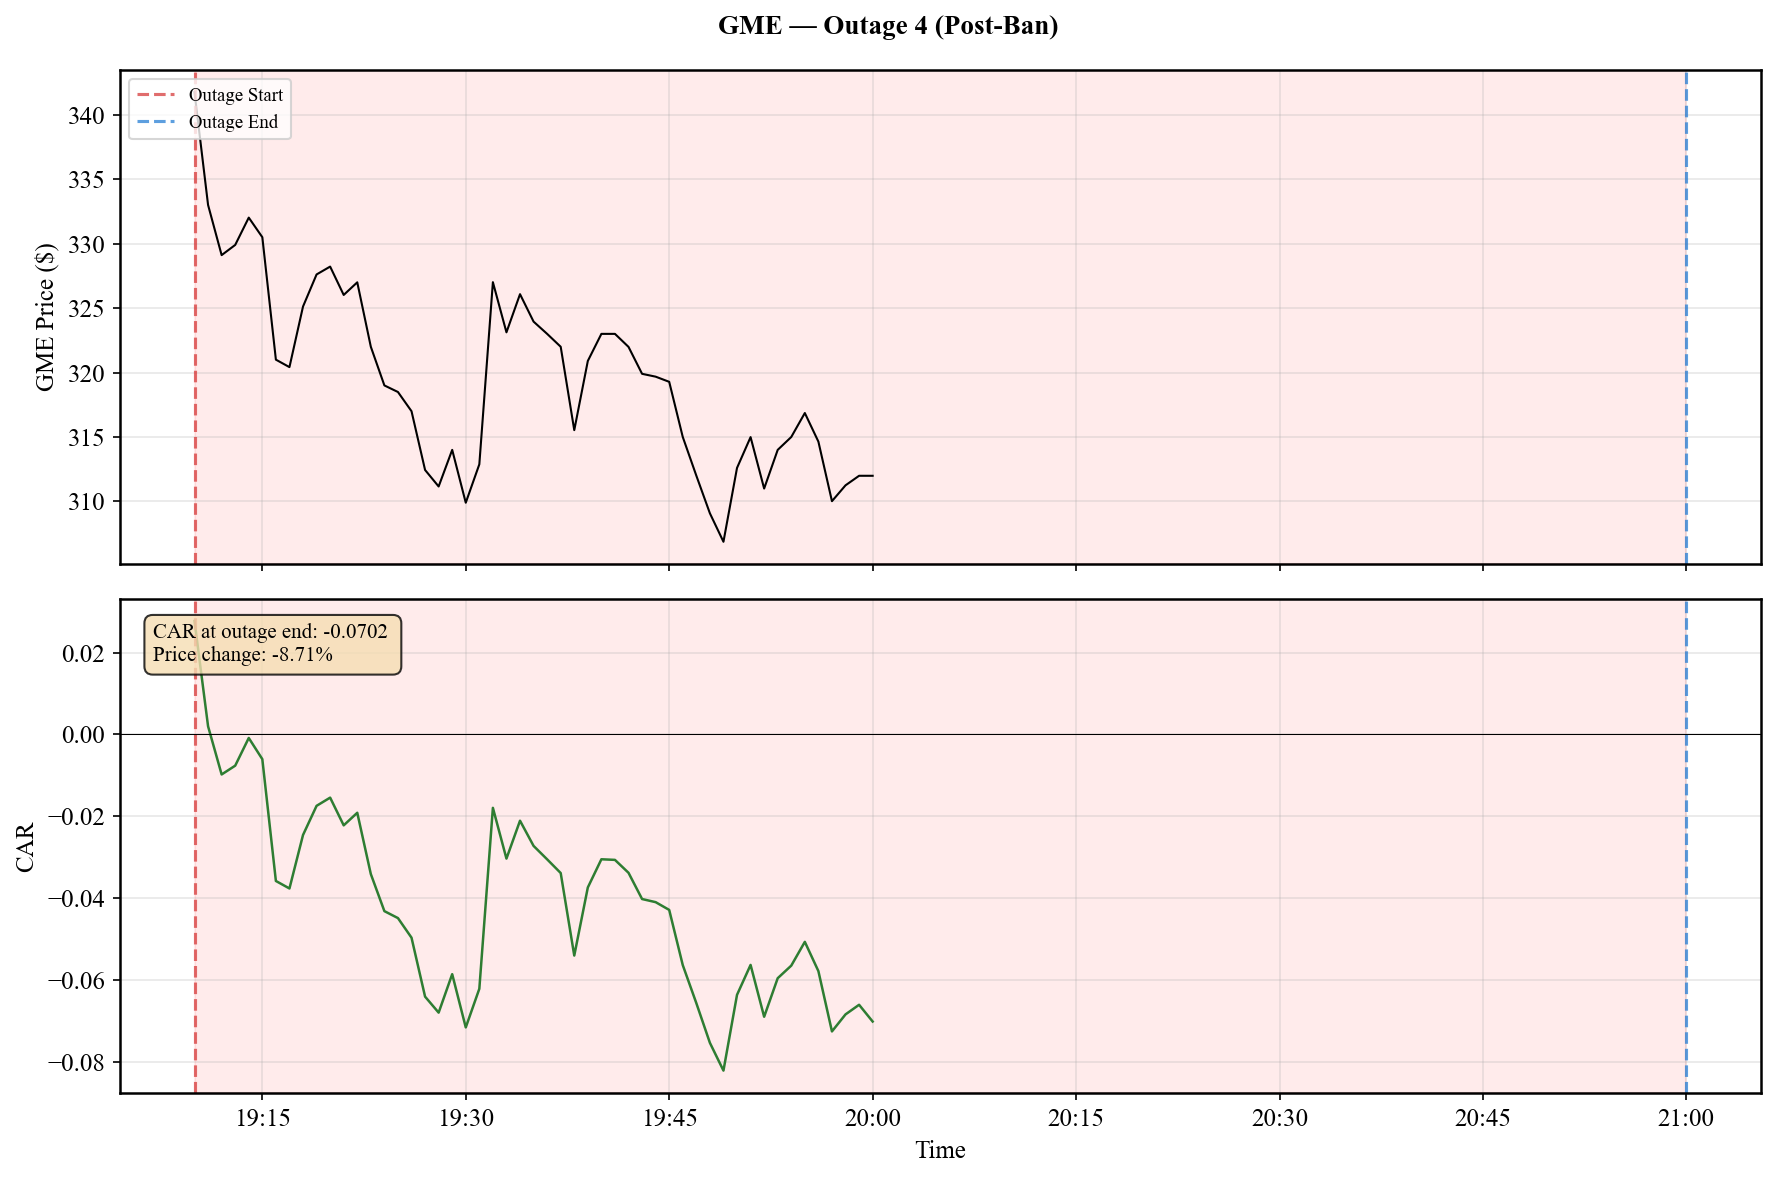


======================================== AMC ========================================


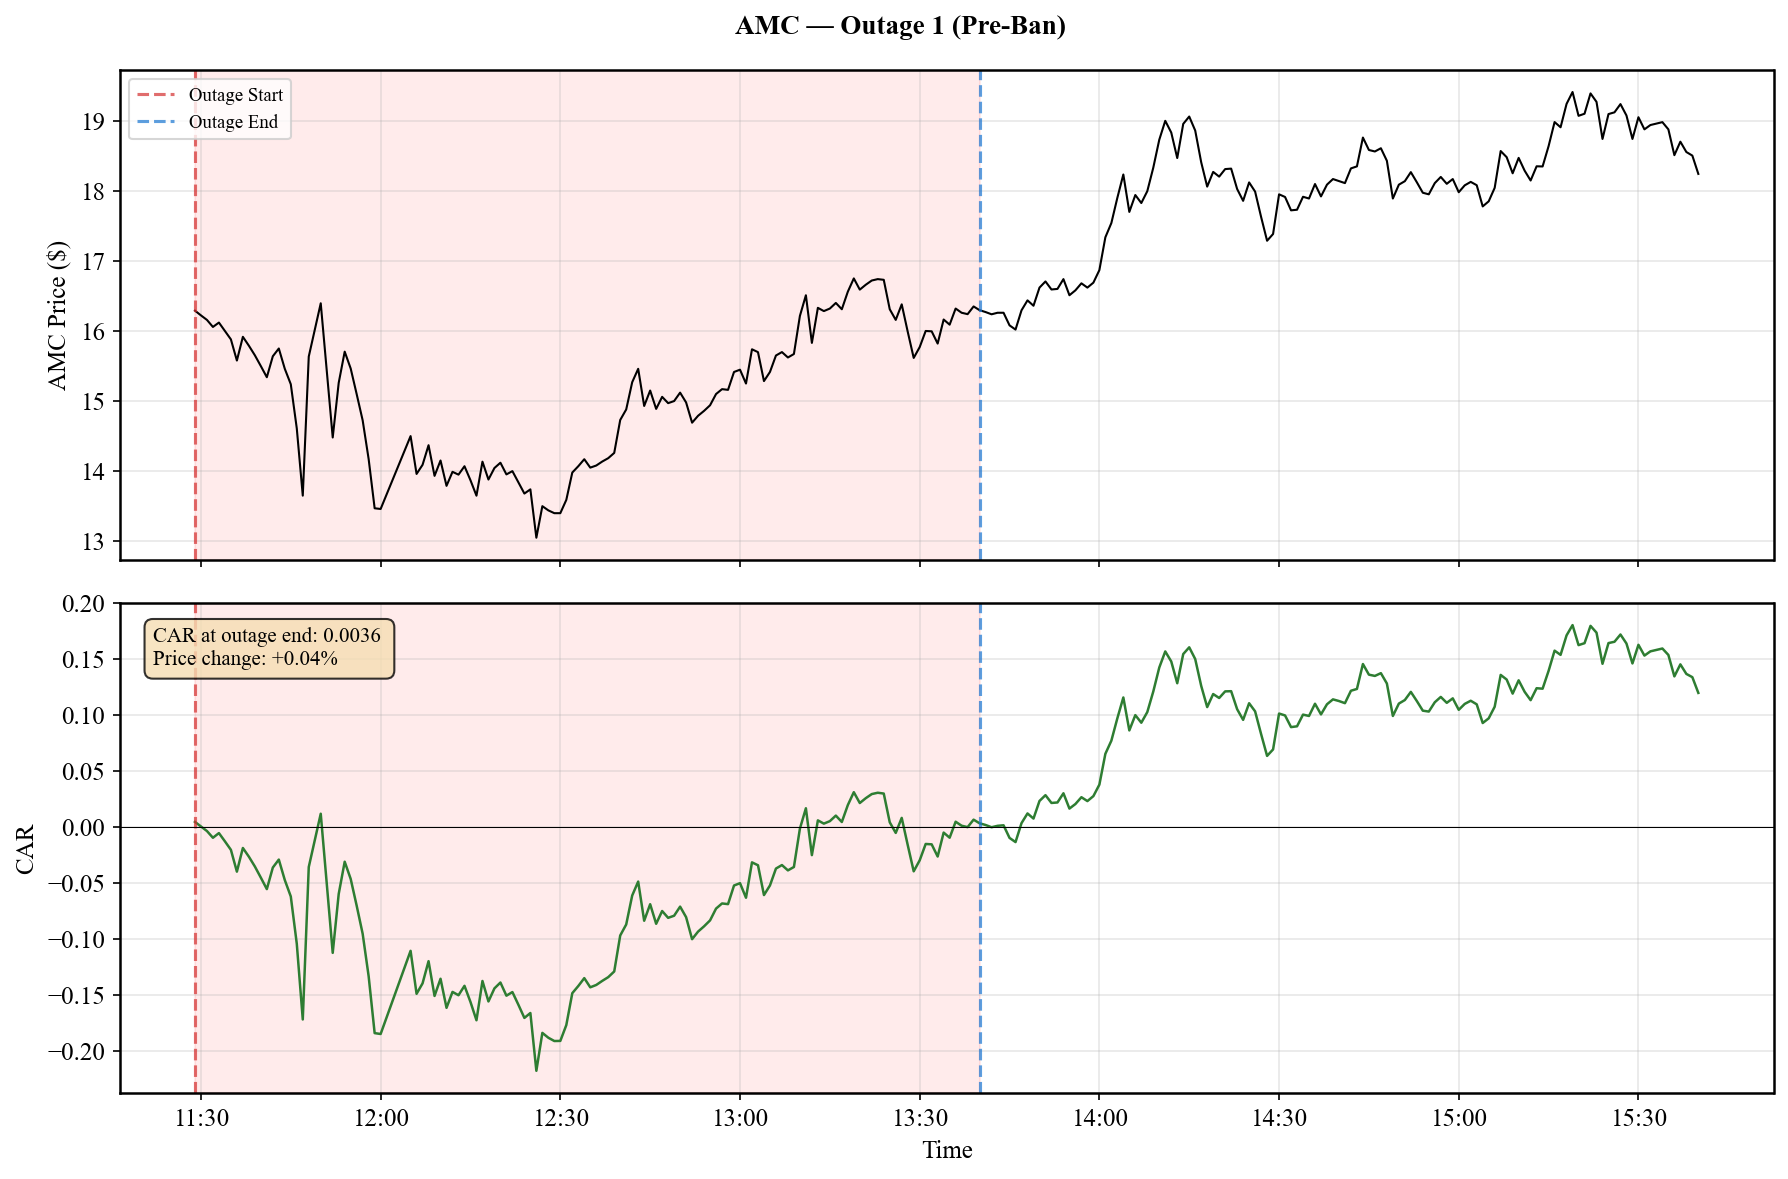

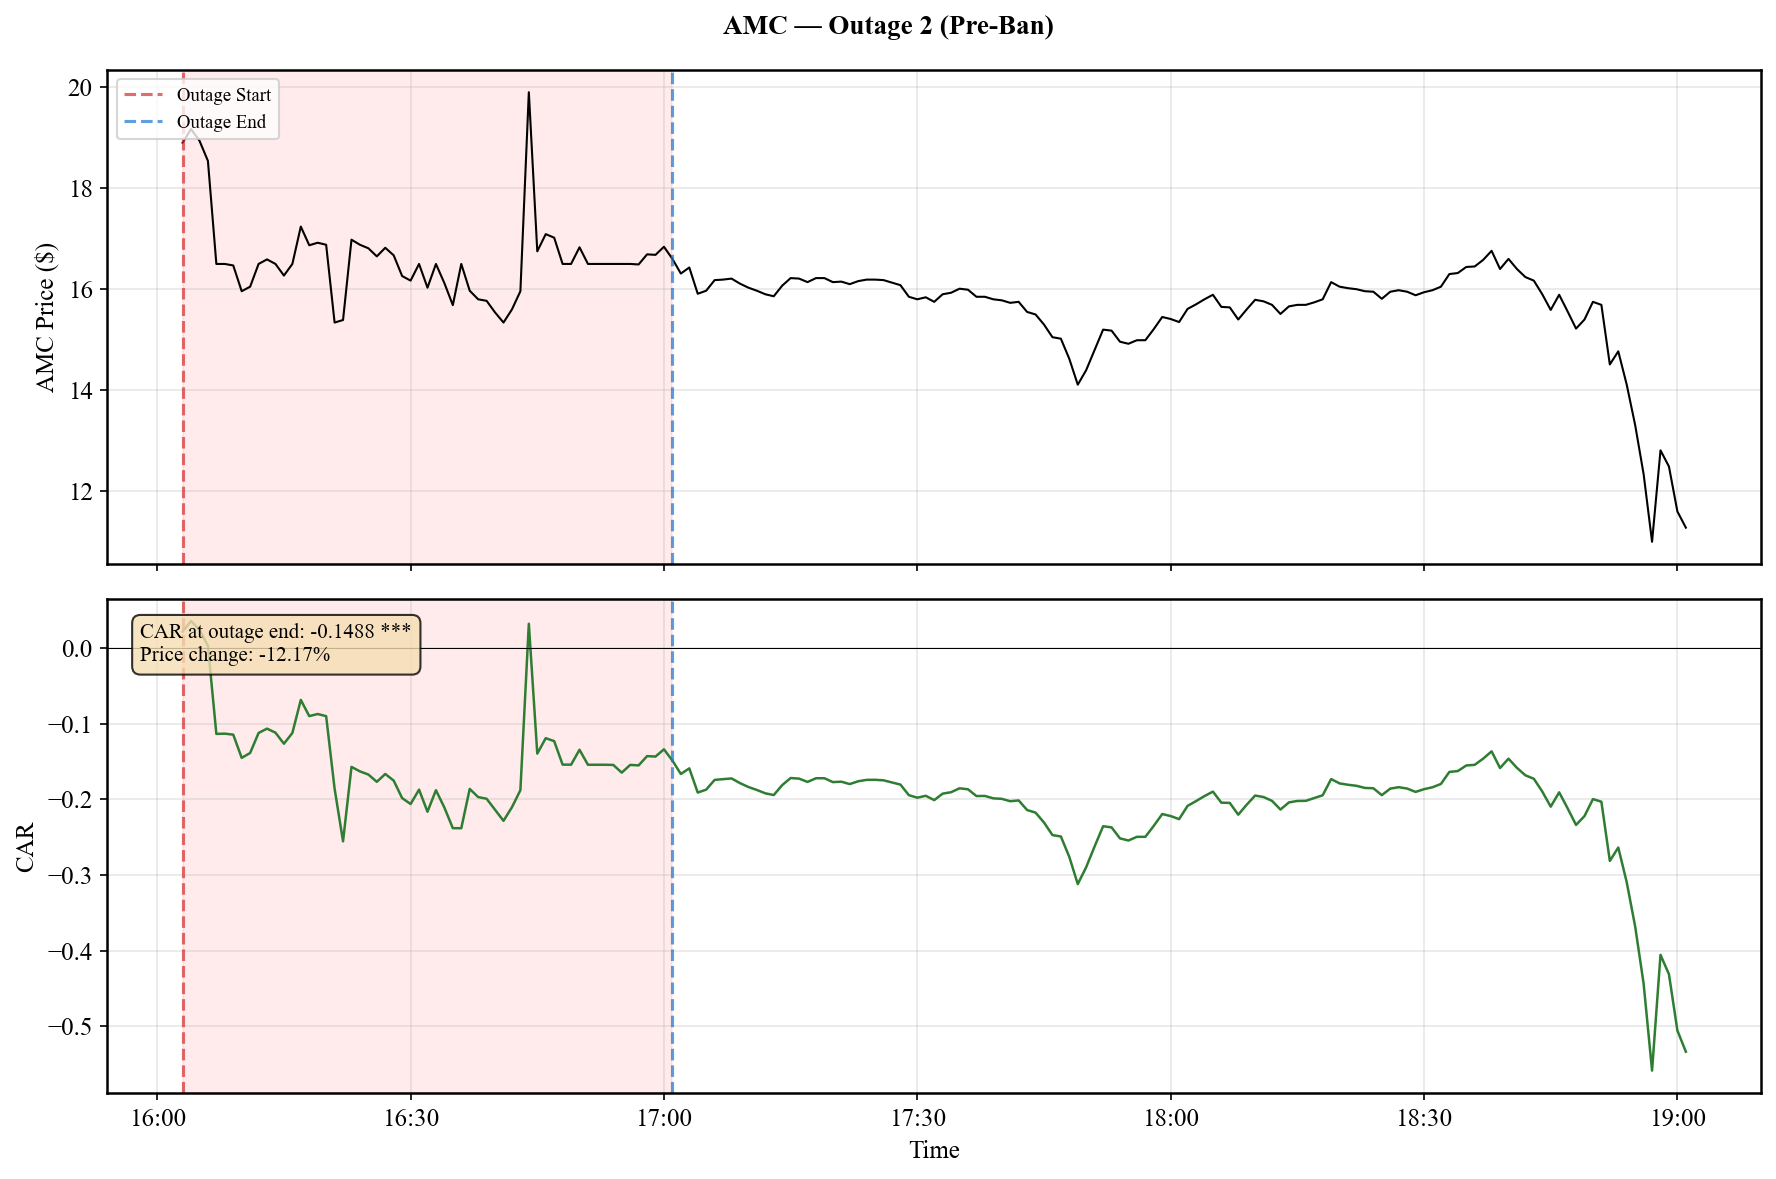

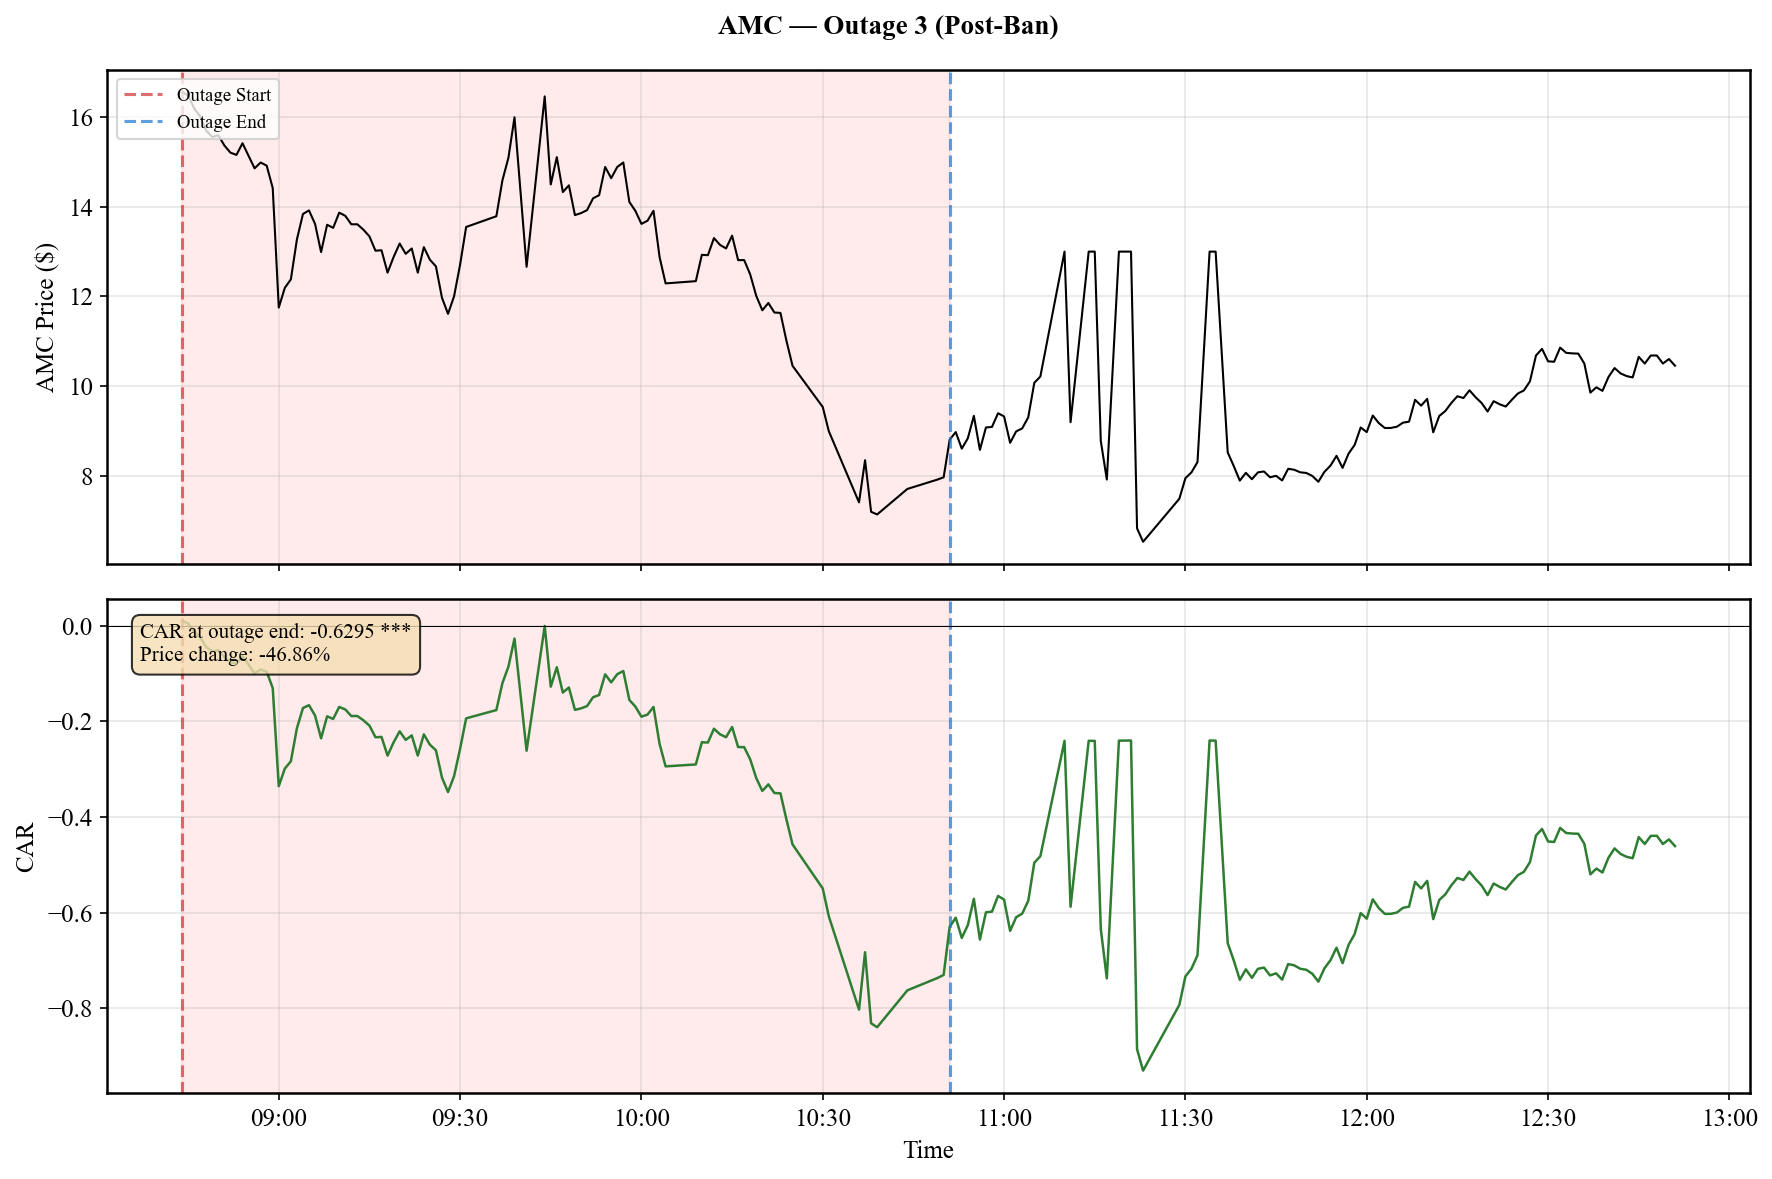

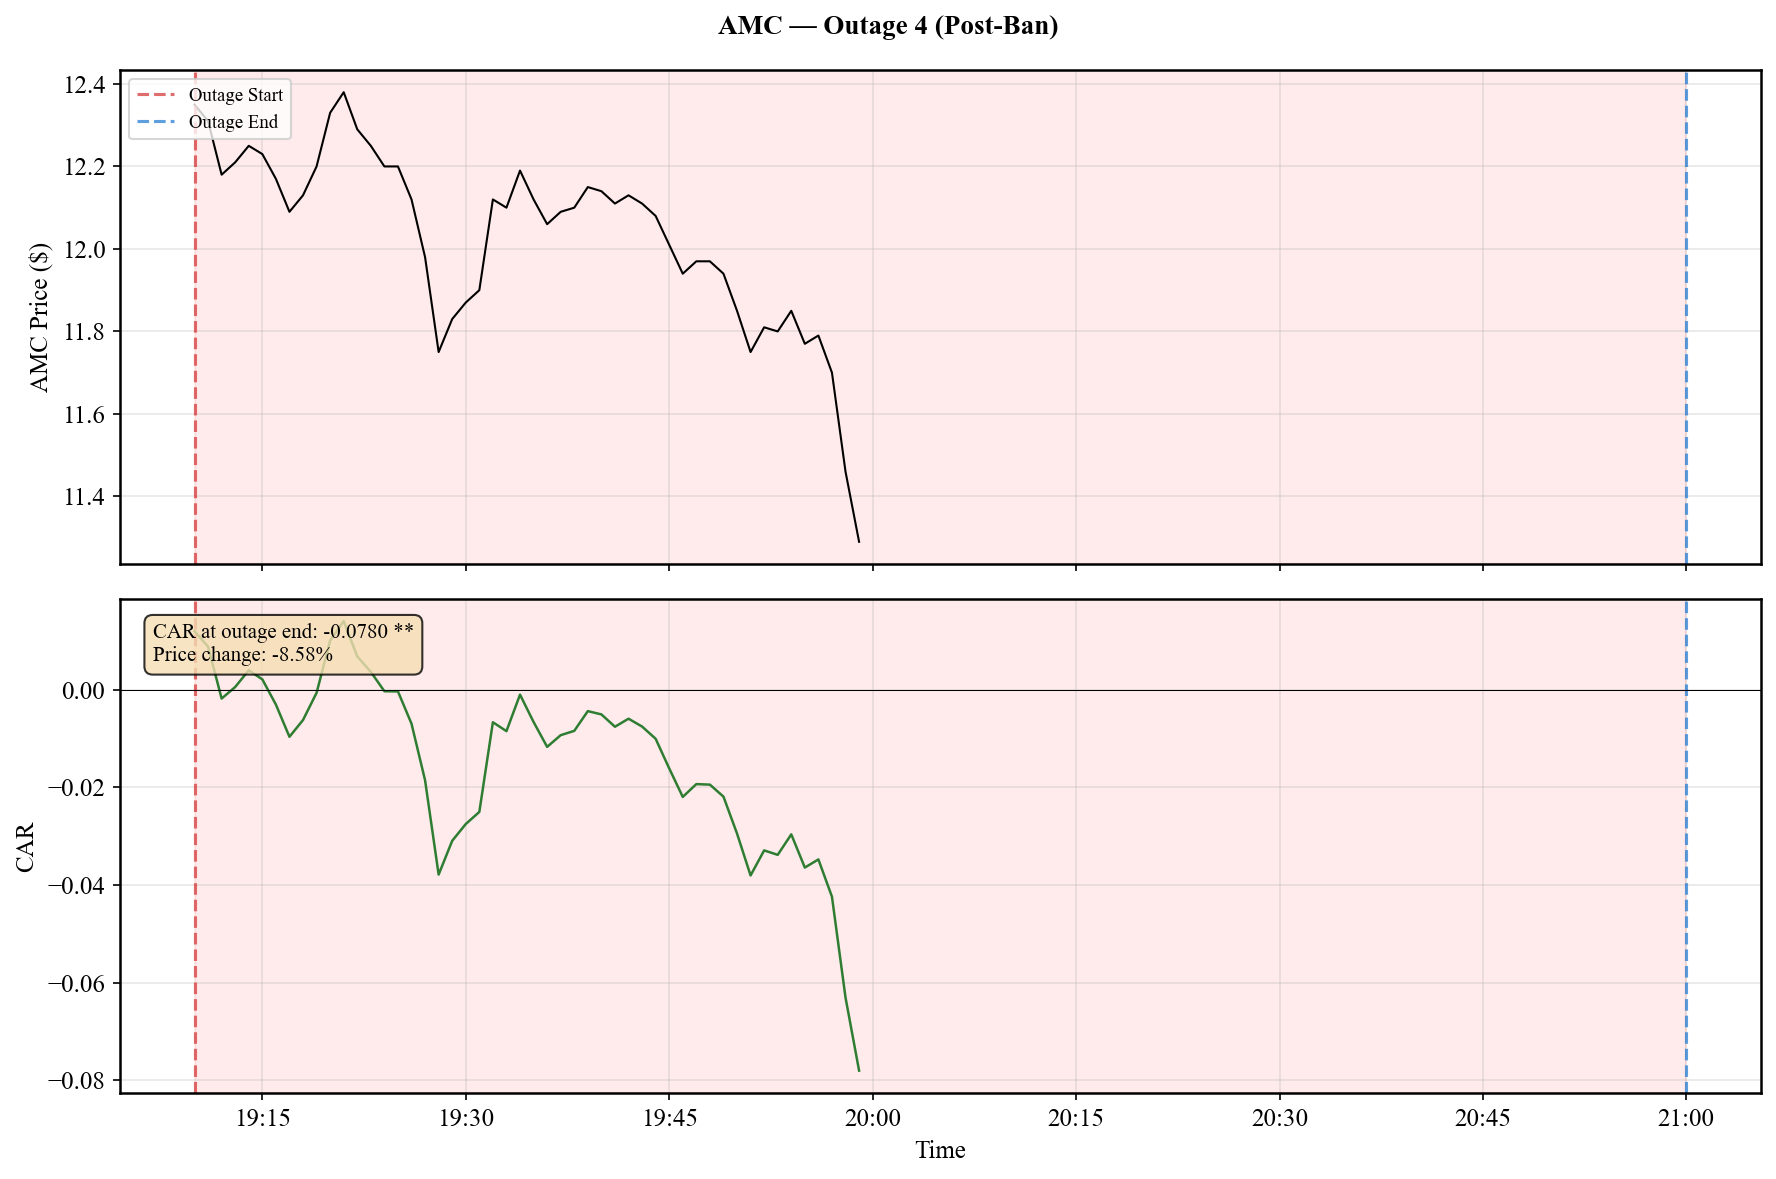

In [12]:
def plot_event_detail(result, symbol, event_num):
    """Two-panel figure: stock price + CAR path for a single outage event."""
    ed = result["event_data"]
    if ed.empty:
        return

    price_col = STOCKS[symbol]["price_col"]
    event_start = result["start_time"]
    event_end = result["end_time"]

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
    fig.suptitle(f"{symbol} — {result['event_name']}", fontsize=13,
                 fontweight="bold")

    # Top: price
    ax1.plot(ed.index, ed[price_col], color="black", linewidth=1.0)
    ax1.axvline(event_start, color=PRE_BAN_COLOR, linestyle="--",
                alpha=0.7, label="Outage Start")
    ax1.axvline(event_end, color=POST_BAN_COLOR, linestyle="--",
                alpha=0.7, label="Outage End")
    ax1.axvspan(event_start, event_end, alpha=0.08, color="red")
    ax1.set_ylabel(f"{symbol} Price ($)")
    ax1.legend(loc="upper left", fontsize=9)
    ax1.grid(alpha=0.3)

    # Bottom: CAR
    ax2.plot(ed.index, ed["CAR"], color="#2E7D32", linewidth=1.2)
    ax2.axvline(event_start, color=PRE_BAN_COLOR, linestyle="--", alpha=0.7)
    ax2.axvline(event_end, color=POST_BAN_COLOR, linestyle="--", alpha=0.7)
    ax2.axvspan(event_start, event_end, alpha=0.08, color="red")
    ax2.axhline(0, color="black", linewidth=0.5)
    ax2.set_ylabel("CAR")
    ax2.set_xlabel("Time")
    ax2.grid(alpha=0.3)

    # Annotation box
    car_end = result["CAR_at_outage_end"]
    pchg = result["price_change_pct"]
    stars = significance_stars(result["p_value"])
    annotation = (f"CAR at outage end: {car_end:.4f} {stars}\n"
                  f"Price change: {pchg:+.2f}%")
    ax2.text(0.02, 0.95, annotation, transform=ax2.transAxes,
             fontsize=10, verticalalignment="top",
             bbox=dict(boxstyle="round,pad=0.4", facecolor="wheat", alpha=0.8))

    ax2.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    plt.tight_layout()

    tag = result["event_name"].lower().replace(" ", "_").replace("(", "").replace(")", "")
    fig.savefig(FIGURES_DIR / symbol.lower() / f"event_{event_num}_{tag}.png")
    plt.show()


for symbol in ["GME", "AMC"]:
    print(f"\n{'='*40} {symbol} {'='*40}")
    for i, r in enumerate(all_results[symbol], 1):
        plot_event_detail(r, symbol, i)

### 8c. Pre-Ban vs Post-Ban Summary (Both Stocks)

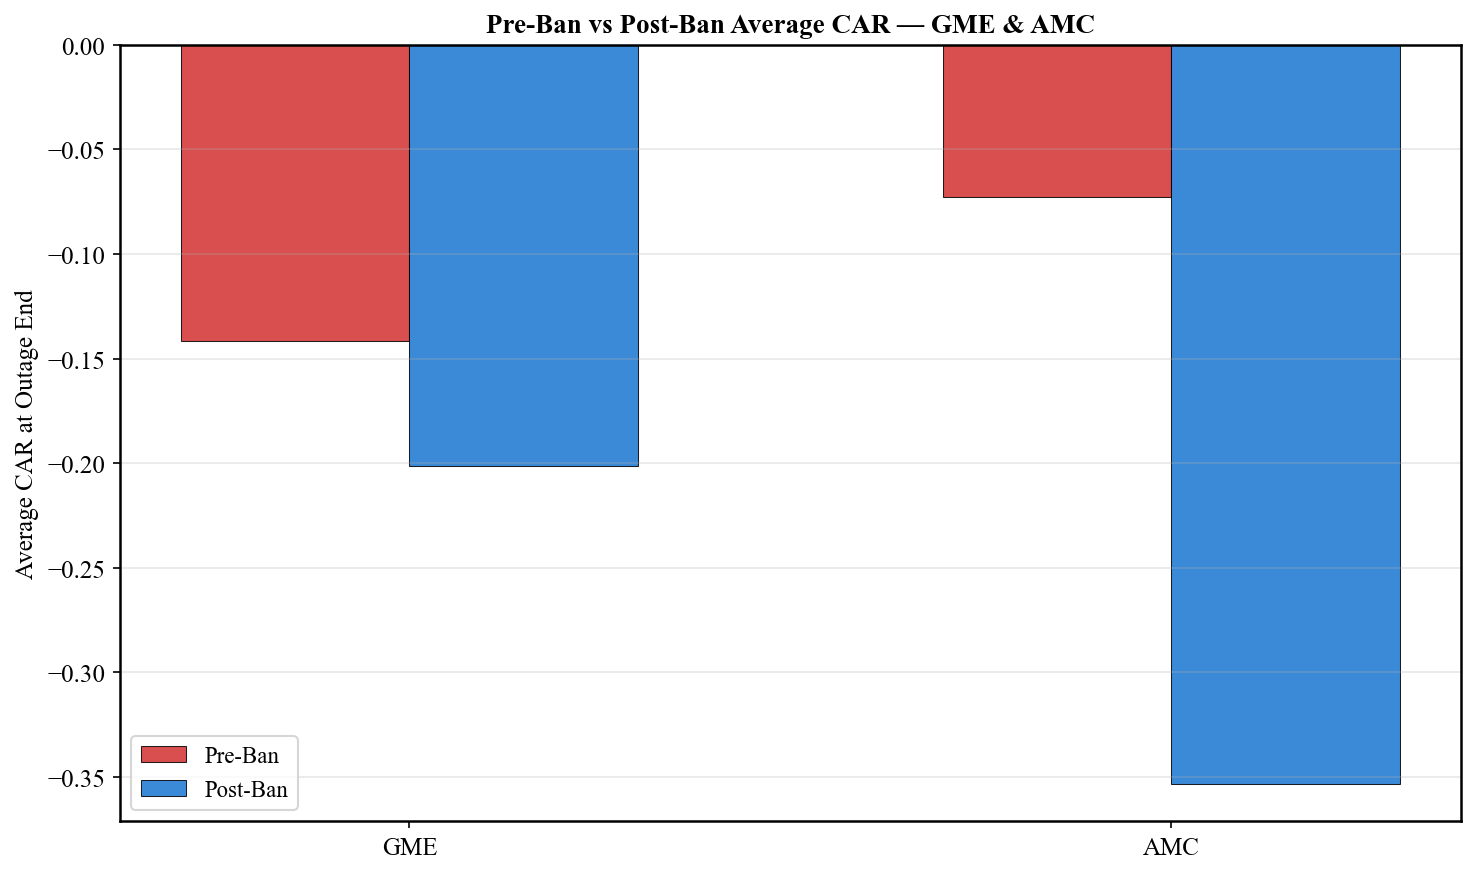

In [13]:
def plot_pre_vs_post_ban_summary(all_results):
    """Grouped bar chart comparing GME and AMC CARs, pre-ban vs post-ban."""
    fig, ax = plt.subplots(figsize=(10, 6))

    symbols = list(all_results.keys())
    x = np.arange(len(symbols))
    width = 0.3

    for i, label, color in [(0, "Pre-Ban", PRE_BAN_COLOR),
                             (1, "Post-Ban", POST_BAN_COLOR)]:
        means = []
        for sym in symbols:
            cars = [r["CAR_at_outage_end"] for r in all_results[sym]
                    if r["pre_ban"] == (label == "Pre-Ban")]
            means.append(np.mean(cars) if cars else 0)
        ax.bar(x + i * width - width / 2, means, width, label=label,
               color=color, alpha=0.85, edgecolor="black", linewidth=0.5)

    ax.set_xticks(x)
    ax.set_xticklabels(symbols, fontsize=12)
    ax.set_ylabel("Average CAR at Outage End")
    ax.set_title("Pre-Ban vs Post-Ban Average CAR — GME & AMC",
                 fontsize=13, fontweight="bold")
    ax.axhline(0, color="black", linewidth=0.5)
    ax.legend(fontsize=11)
    ax.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    fig.savefig(FIGURES_DIR / "pre_vs_post_ban_summary.png")
    plt.show()


plot_pre_vs_post_ban_summary(all_results)

---
## 9. Summary of Findings

Display the final results table and key takeaways.

In [14]:
print("="*70)
print("  SUMMARY: Reddit Outage Impact on Meme Stock Returns")
print("="*70)

for symbol in ["GME", "AMC"]:
    results = all_results[symbol]
    pre_cars = [r["CAR_at_outage_end"] for r in results if r["pre_ban"]]
    post_cars = [r["CAR_at_outage_end"] for r in results if not r["pre_ban"]]

    print(f"\n--- {symbol} ---")
    print(f"  Pre-ban avg CAR:  {np.mean(pre_cars):+.4f}")
    print(f"  Post-ban avg CAR: {np.mean(post_cars):+.4f}")
    print(f"  Difference:       {np.mean(post_cars) - np.mean(pre_cars):+.4f}")

    sig_events = [r for r in results if r["p_value"] < 0.05]
    print(f"  Significant events (p<0.05): {len(sig_events)}/{len(results)}")
    for r in sig_events:
        print(f"    - {r['event_name']}: CAR={r['CAR_at_outage_end']:.4f}, "
              f"t={r['t_stat']:.2f}, p={r['p_value']:.4f} {significance_stars(r['p_value'])}")

print(f"\nAll output files saved to: {OUTPUT_DIR}")
print(f"Figures saved to: {FIGURES_DIR}")

  SUMMARY: Reddit Outage Impact on Meme Stock Returns

--- GME ---
  Pre-ban avg CAR:  -0.1418
  Post-ban avg CAR: -0.2014
  Difference:       -0.0596
  Significant events (p<0.05): 2/4
    - Outage 2 (Pre-Ban): CAR=-0.1528, t=-2.21, p=0.0271 **
    - Outage 3 (Post-Ban): CAR=-0.3326, t=-3.60, p=0.0003 ***

--- AMC ---
  Pre-ban avg CAR:  -0.0726
  Post-ban avg CAR: -0.3537
  Difference:       -0.2811
  Significant events (p<0.05): 3/4
    - Outage 2 (Pre-Ban): CAR=-0.1488, t=-3.66, p=0.0003 ***
    - Outage 3 (Post-Ban): CAR=-0.6295, t=-11.84, p=0.0000 ***
    - Outage 4 (Post-Ban): CAR=-0.0780, t=-2.08, p=0.0371 **

All output files saved to: /Users/rajvardhan/Desktop/Projects/RA-MemeStocks/Rajvardhan workspace/output/spy-only
Figures saved to: /Users/rajvardhan/Desktop/Projects/RA-MemeStocks/Rajvardhan workspace/output/spy-only/figures
